In [68]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from IPython.display import display
import shutil
import math

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_colwidth', 60)

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

NOTEBOOK_DIR = Path(os.getcwd())           # sprint1/
DATA_DIR     = NOTEBOOK_DIR/ 'data'
OUT_DIR      = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

print(f'DATA_DIR  : {DATA_DIR}')
print(f'OUT_DIR   : {OUT_DIR}')


os.makedirs('./data', exist_ok=True)


files = {
    'AIR_AIR Temperatures (ALL)-data-as-joinbyfield-2026-02-12 08_56_48.csv': 'air_temperature.csv',
    'AIR_ePAR (all parameters)-data-as-joinbyfield-2026-02-12 09_00_37.csv': 'par_radiation.csv',
    'PV_Irradiance-data-as-joinbyfield-2026-02-12 14_17_50.csv':              'pv_irradiance.csv',
    'PV_PV panel temperatures-data-as-joinbyfield-2026-02-12 14_18_22.csv':   'pv_panel_temperature.csv',
    'Precipitation (Total  Difference cumulative sum)-data-2026-02-12 14_23_21.csv': 'precipitation_cumulative.csv',
    'Precipitation-data-as-joinbyfield-2026-02-12 14_21_47.csv':              'precipitation_intensity.csv',
    'Precipitation_type_-data-2026-02-12 09_01_21.csv':                       'precipitation_type.csv',
    'SOIL_Temperature-data-as-joinbyfield-2026-02-12 08_54_57.csv':           'soil_temperature.csv',
    'SOIL_VWC-data-as-joinbyfield-2026-02-12 08_57_18.csv':                   'soil_vwc.csv',
    'Tracking angles-data-as-joinbyfield-2026-02-12 14_24_26.csv':            'tracker_angles.csv',
    'Wind direction-data-2026-02-12 14_25_08.csv':                            'wind_direction.csv',
    'Wind speed-data-2026-02-12 09_05_40.csv':                                'wind_speed.csv',
}

for original, nou in files.items():
    src = f'../data/{original}'
    dst = f'./data/{nou}'
    shutil.copy2(src, dst)
    print(f'{original}\n   -> {nou}\n')

DATA_DIR  : /home/pablo/GIA/PIA/PIA_lab/sprint1/data
OUT_DIR   : /home/pablo/GIA/PIA/PIA_lab/sprint1/outputs
AIR_AIR Temperatures (ALL)-data-as-joinbyfield-2026-02-12 08_56_48.csv
   -> air_temperature.csv

AIR_ePAR (all parameters)-data-as-joinbyfield-2026-02-12 09_00_37.csv
   -> par_radiation.csv

PV_Irradiance-data-as-joinbyfield-2026-02-12 14_17_50.csv
   -> pv_irradiance.csv

PV_PV panel temperatures-data-as-joinbyfield-2026-02-12 14_18_22.csv
   -> pv_panel_temperature.csv

Precipitation (Total  Difference cumulative sum)-data-2026-02-12 14_23_21.csv
   -> precipitation_cumulative.csv

Precipitation-data-as-joinbyfield-2026-02-12 14_21_47.csv
   -> precipitation_intensity.csv

Precipitation_type_-data-2026-02-12 09_01_21.csv
   -> precipitation_type.csv

SOIL_Temperature-data-as-joinbyfield-2026-02-12 08_54_57.csv
   -> soil_temperature.csv

SOIL_VWC-data-as-joinbyfield-2026-02-12 08_57_18.csv
   -> soil_vwc.csv

Tracking angles-data-as-joinbyfield-2026-02-12 14_24_26.csv
   -> 

In [53]:
# ── Helpers de carga ────────────────────────────────────────────────────────

def strip_unit(series: pd.Series) -> pd.Series:
    """Extrae el valor numérico de strings tipo '28.8 °C', '1024 W/m²', '41.4 °'."""
    if pd.api.types.is_string_dtype(series) or series.dtype == object:
        cleaned = series.astype(str).str.extract(r'([\-\d\.]+)', expand=False)
        return pd.to_numeric(cleaned, errors='coerce')
    return series


def detect_sep_line(filepath: Path) -> int:
    """Devuelve cuántas filas de cabecera extra saltar (0 o 1 si tiene 'sep=')."""
    with open(filepath, 'r', encoding='utf-8-sig') as f:
        first = f.readline().strip()
    return 1 if first.lower().startswith('sep=') else 0


def load_csv(filepath: Path, nrows: int = None) -> pd.DataFrame:
    """Carga un CSV manejando la línea sep= y el BOM UTF-8."""
    skip = detect_sep_line(filepath)
    df = pd.read_csv(
        filepath,
        skiprows=skip,
        encoding='utf-8-sig',
        nrows=nrows,
        low_memory=False
    )
    # Normalizar la columna temporal
    time_cols = [c for c in df.columns if c.strip().lower() == 'time']
    if time_cols:
        df = df.rename(columns={time_cols[0]: 'Time'})
        df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
    return df


def strip_all_units(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica strip_unit a todas las columnas no-Time."""
    df = df.copy()
    for col in df.columns:
        if col != 'Time':
            df[col] = strip_unit(df[col])
    return df

In [54]:

def load(filename):
    """Carrega un CSV del projecte gestionant la capçalera 'sep='"""
    with open(filename, encoding='utf-8-sig') as f:
        first = f.readline().strip()
    skip = 1 if first == 'sep=,' else 0
    df = pd.read_csv(filename, skiprows=skip, encoding='utf-8-sig', low_memory=False)
    if 'Time' in df.columns:
        df['Time'] = pd.to_datetime(df['Time'])
    return df



files = {
    'air_temp': 'air_temperature.csv',
    'par_rad': 'par_radiation.csv',
    'precip_int': 'precipitation_intensity.csv',
    'precip_type': 'precipitation_type.csv',
    'pv_irrad': 'pv_irradiance.csv',
    'pv_temp': 'pv_panel_temperature.csv',
    'soil_temp': 'soil_temperature.csv',
    'soil_vwc': 'soil_vwc.csv',
    'trackers': 'tracker_angles.csv'
}


data = {k: load(os.path.join(DATA_DIR, v)) for k, v in files.items()}

print("Todos los datasets cargados correctamente desde la carpeta:", DATA_DIR)


Todos los datasets cargados correctamente desde la carpeta: /home/pablo/GIA/PIA/PIA_lab/sprint1/data


In [55]:
def quality_report(name: str, df: pd.DataFrame) -> dict:
    """Genera métricas de calidad para un dataframe."""
    n = len(df)
    non_time_cols = [c for c in df.columns if c != 'Time']
    
    df_num = strip_all_units(df[non_time_cols]) if non_time_cols else pd.DataFrame()
    
    null_pct_mean  = df_num.isnull().mean().mean() * 100 if not df_num.empty else 0
    dup_rows       = df.duplicated().sum()
    time_nulls     = df['Time'].isnull().sum() if 'Time' in df.columns else 0
    const_cols     = [c for c in df_num.columns if df_num[c].nunique() <= 1]
    high_null_cols = [c for c in df_num.columns if df_num[c].isnull().mean() > 0.95]
    med_high_null_cols = [c for c in df_num.columns if df_num[c].isnull().mean() > 0.75]
    med_null_cols = [c for c in df_num.columns if df_num[c].isnull().mean() > 0.5]

    freq_str = 'N/A'
    if 'Time' in df.columns and n > 2:
        deltas = df['Time'].dropna().sort_values().diff().dropna()
        if not deltas.empty:
            median_delta = deltas.median()
            freq_str = str(median_delta)
            
    time_min = 'N/A'
    time_max = 'N/A'
    if 'Time' in df.columns and not df['Time'].dropna().empty:
        time_min = str(df['Time'].min())
        time_max = str(df['Time'].max())
    
    return {
        'Dataset':           name,
        'Filas':             n,
        'Columnas':          len(df.columns),
        'Nulos promedio %':  round(null_pct_mean, 1),
        'Filas duplicadas':  int(dup_rows),
        'Time nulos':        int(time_nulls),
        'Time min':          time_min,  # NUEVO
        'Time max':          time_max,  # NUEVO
        'Cols constantes':   len(const_cols),
        'Cols >95% nulo':    len(high_null_cols),
        'Cols >75% nulo':    len(med_high_null_cols),
        'Cols >50% nulo':    len(med_null_cols),
        'Frecuencia aprox.': freq_str,
        'Cols const. nombres': ', '.join(const_cols[:5]) or '-',
    }

quality_rows = []
for name, df in data.items():
    quality_rows.append(quality_report(name, df))

quality_df = pd.DataFrame(quality_rows)

# Aseguramos que las nuevas columnas aparezcan en el display
display(quality_df[[
    'Dataset','Filas','Columnas','Nulos promedio %',
    'Filas duplicadas','Time nulos', 'Time min', 'Time max', 
    'Cols constantes', 'Cols >95% nulo', 'Cols >75% nulo', 'Cols >50% nulo', 'Frecuencia aprox.'
]])

# Guardar
OUT_DIR.mkdir(parents=True, exist_ok=True)
quality_df.to_csv(OUT_DIR / 'quality_report.csv', index=False)
print('\n=> Guardado en outputs/quality_report.csv')

,Dataset,Filas,Columnas,Nulos promedio %,Filas duplicadas,Time nulos,Time min,Time max,Cols constantes,Cols >95% nulo,Cols >75% nulo,Cols >50% nulo,Frecuencia aprox.
0,air_temp,1461,13,37.400,0,0,2025-02-12 07:00:00,2026-02-12 07:00:00,0,0,0,0,0 days 06:00:00
1,par_rad,1461,25,37.100,0,0,2025-02-12 07:00:00,2026-02-12 07:00:00,0,0,0,0,0 days 06:00:00
2,precip_int,605682,3,46.900,0,0,2025-06-16 11:55:30,2026-02-12 14:20:00,0,0,0,1,0 days 00:00:30
3,precip_type,605010,2,100.000,0,0,2025-06-16 11:55:30,2026-02-12 08:44:00,1,1,1,1,0 days 00:00:30
4,pv_irrad,1753,5,29.600,0,0,2025-05-12 04:00:00,2025-10-05 04:00:00,0,0,0,0,0 days 02:00:00
5,pv_temp,1753,9,29.600,0,0,2025-05-12 04:00:00,2025-10-05 04:00:00,0,0,0,0,0 days 02:00:00
6,soil_temp,1461,15,44.700,0,0,2025-02-12 07:00:00,2026-02-12 07:00:00,0,0,0,2,0 days 06:00:00
7,soil_vwc,1461,15,46.600,0,0,2025-02-12 07:00:00,2026-02-12 07:00:00,0,0,0,3,0 days 06:00:00
8,trackers,1461,11,30.500,0,0,2025-02-12 13:00:00,2026-02-12 13:00:00,0,0,0,0,0 days 06:00:00



=> Guardado en outputs/quality_report.csv


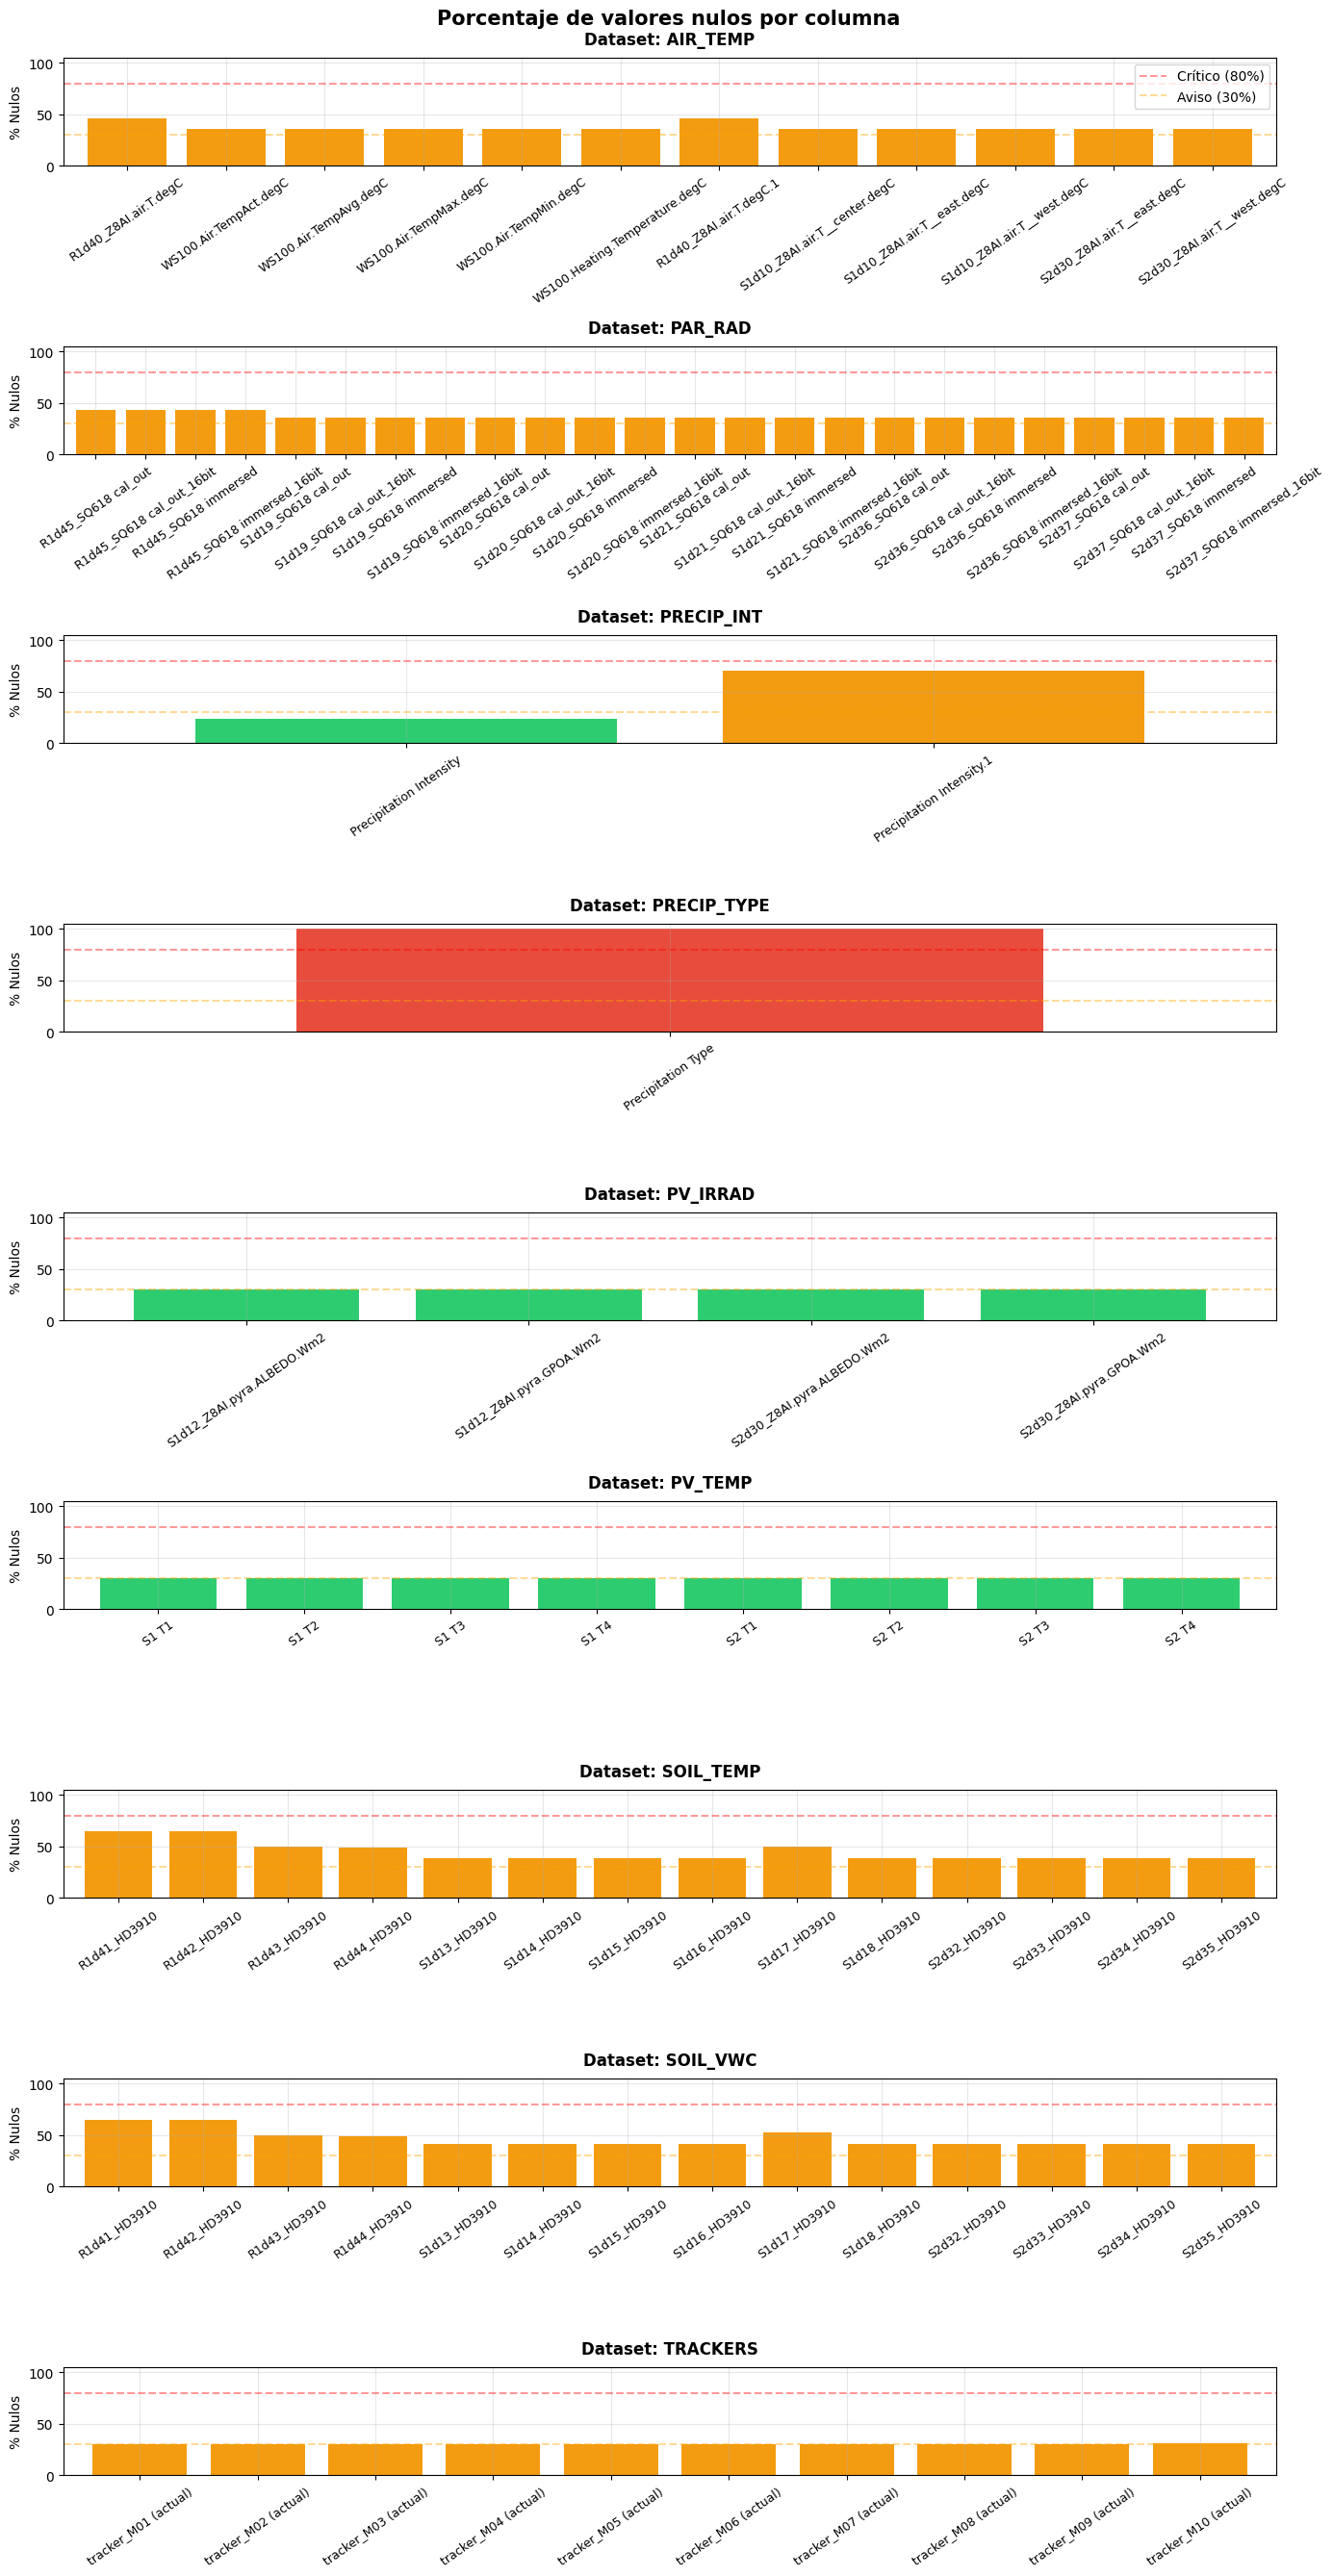


=> Gráfico guardado en outputs/nulls_by_column.png


In [56]:



fig, axes = plt.subplots(len(data), 1, figsize=(14, 3 * len(data)))
fig.suptitle('Porcentaje de valores nulos por columna', fontsize=15, fontweight='bold', y=0.99)

for ax, name in zip(axes, data):
    if name in data:
        df_n = strip_all_units(data[name].drop(columns=['Time'], errors='ignore'))
        
        # Calculamos % de nulos
        null_pct = df_n.isnull().mean() * 100
        
        colors = ['#e74c3c' if v > 80 else '#f39c12' if v > 30 else '#2ecc71' for v in null_pct]
        
        # Dibujamos el gráfico de barras
        null_pct.plot(kind='bar', ax=ax, color=colors, width=0.8)
        
        # Formato del subplot
        ax.set_title(f'Dataset: {name.upper()}', fontweight='bold', pad=10)
        ax.set_ylabel('% Nulos')
        ax.set_ylim(0, 105)
        ax.axhline(80, color='red', linestyle='--', alpha=0.4, label='Crítico (80%)')
        ax.axhline(30, color='orange', linestyle='--', alpha=0.4, label='Aviso (30%)')
        
        # Ajustamos las etiquetas para que sean legibles
        ax.tick_params(axis='x', rotation=35, labelsize=9)
        
        # Añadimos leyenda solo en el primero para no saturar visualmente
        if ax == axes[0]:
            ax.legend(loc='upper right')

plt.tight_layout()

# Aseguramos que el directorio exista antes de guardar
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_DIR / 'nulls_by_column.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=> Gráfico guardado en outputs/nulls_by_column.png')

In [57]:
def temporal_summary(name: str, df: pd.DataFrame) -> dict:
    if 'Time' not in df.columns:
        return {'Dataset': name, 'Error': 'Sin columna Time'}
    ts = df['Time'].dropna().sort_values()
    if len(ts) < 2:
        return {'Dataset': name, 'Error': 'Menos de 2 timestamps válidos'}
    deltas = ts.diff().dropna()
    median_d = deltas.median()
    max_gap  = deltas.max()
    n_gaps   = (deltas > median_d * 3).sum()  # huecos > 3x frecuencia normal
    return {
        'Dataset':             name,
        'T_inicio':            str(ts.min())[:16],
        'T_fin':               str(ts.max())[:16],
        'Días cubiertos':      round((ts.max() - ts.min()).days, 1),
        'Frecuencia mediana':  str(median_d),
        'Hueco máximo':        str(max_gap),
        'N° huecos grandes':   int(n_gaps),
    }

temporal_rows = [temporal_summary(n, d) for n, d in data.items()]
temp_df = pd.DataFrame(temporal_rows)
display(temp_df)
temp_df.to_csv(OUT_DIR / 'temporal_summary.csv', index=False)

,Dataset,T_inicio,T_fin,Días cubiertos,Frecuencia mediana,Hueco máximo,N° huecos grandes
0,air_temp,2025-02-12 07:00,2026-02-12 07:00,365,0 days 06:00:00,0 days 07:00:00,0
1,par_rad,2025-02-12 07:00,2026-02-12 07:00,365,0 days 06:00:00,0 days 07:00:00,0
2,precip_int,2025-06-16 11:55,2026-02-12 14:20,241,0 days 00:00:30,3 days 02:02:10,3537
3,precip_type,2025-06-16 11:55,2026-02-12 08:44,240,0 days 00:00:30,3 days 02:04:31,3537
4,pv_irrad,2025-05-12 04:00,2025-10-05 04:00,146,0 days 02:00:00,0 days 02:00:00,0
5,pv_temp,2025-05-12 04:00,2025-10-05 04:00,146,0 days 02:00:00,0 days 02:00:00,0
6,soil_temp,2025-02-12 07:00,2026-02-12 07:00,365,0 days 06:00:00,0 days 07:00:00,0
7,soil_vwc,2025-02-12 07:00,2026-02-12 07:00,365,0 days 06:00:00,0 days 07:00:00,0
8,trackers,2025-02-12 13:00,2026-02-12 13:00,365,0 days 06:00:00,0 days 07:00:00,0


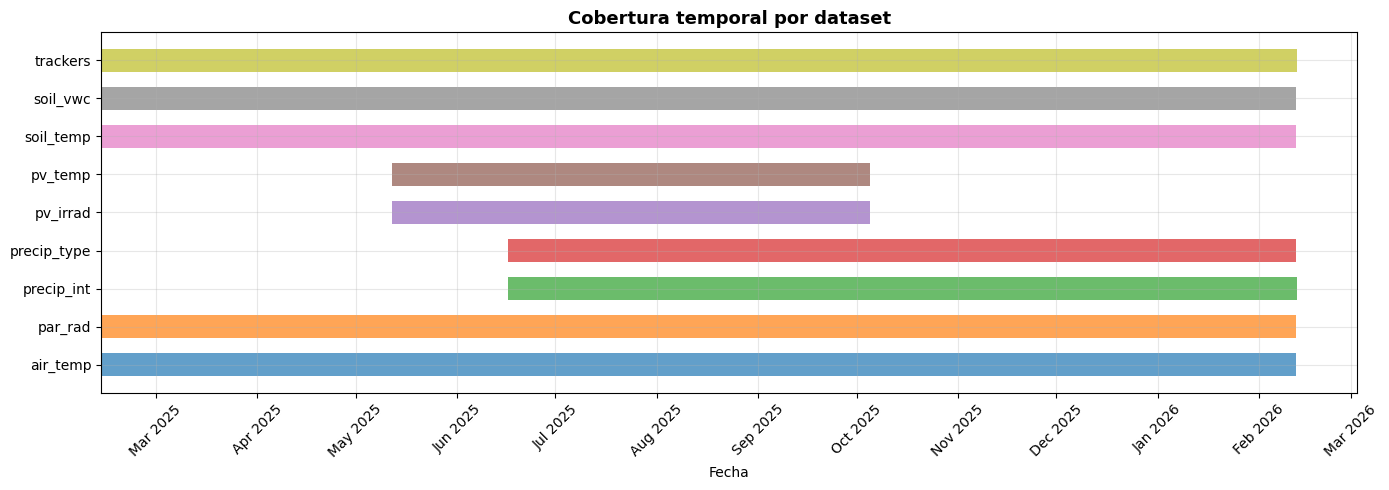

In [58]:
# ── Visualización de cobertura temporal por dataset ─────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

colors_map = plt.cm.tab10.colors
y_pos = 0
yticks, ylabels = [], []

for i, (name, df) in enumerate(data.items()):
    if 'Time' not in df.columns:
        continue
    ts = df['Time'].dropna().sort_values()
    if len(ts) < 2:
        continue
    ax.barh(y_pos, left=ts.min(), width=(ts.max()-ts.min()),
            height=0.6, color=colors_map[i % 10], alpha=0.7, label=name)
    yticks.append(y_pos)
    ylabels.append(name)
    y_pos += 1

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.set_title('Cobertura temporal por dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(OUT_DIR / 'temporal_coverage.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Detección de huecos mayores de 24h en datasets de sensores ──────────────

print('=== Huecos > 24h por dataset ===')
for name in data:
    df = data[name]
    ts = df['Time'].dropna().sort_values()
    gaps = ts.diff().dropna()
    big_gaps = gaps[gaps > pd.Timedelta('24h')]
    if len(big_gaps) > 0:
        print(f'\n{name} — {len(big_gaps)} hueco(s) > 24h:')
        for idx, g in big_gaps.items():
            t_antes = ts.loc[idx - 1] if idx > 0 else 'N/A'
            print(f'   {t_antes}  ->  duración hueco: {g}')
    else:
        print(f'{name} — sin huecos > 24h')

=== Huecos > 24h por dataset ===
air_temp — sin huecos > 24h
par_rad — sin huecos > 24h

precip_int — 3 hueco(s) > 24h:
   2025-06-16 11:55:30  →  duración hueco: 2 days 03:15:30
   2025-08-11 05:41:20  →  duración hueco: 3 days 02:02:10
   2025-08-16 07:20:30  →  duración hueco: 1 days 10:57:36

precip_type — 3 hueco(s) > 24h:
   2025-06-16 11:55:30  →  duración hueco: 2 days 03:15:30
   2025-08-11 05:38:59  →  duración hueco: 3 days 02:04:31
   2025-08-16 07:20:30  →  duración hueco: 1 days 10:57:36
pv_irrad — sin huecos > 24h
pv_temp — sin huecos > 24h
soil_temp — sin huecos > 24h
soil_vwc — sin huecos > 24h
trackers — sin huecos > 24h


In [63]:
# ── Versiones numéricas de los datasets principales ─────────────────────────
dfs_num = {k: strip_all_units(data[k]) for k in data}
for k in data:
    dfs_num[k]['Time'] = data[k]['Time']

print('Versiones numéricas preparadas.')

for k, df in dfs_num.items():
    n_num = df.select_dtypes(include=np.number).shape[1]
    print(f'  {k:12s} -> {n_num} cols numèriques de {df.shape[1]} totals')

Versiones numéricas preparadas.
  air_temp     -> 12 cols numèriques de 13 totals
  par_rad      -> 24 cols numèriques de 25 totals
  precip_int   -> 2 cols numèriques de 3 totals
  precip_type  -> 1 cols numèriques de 2 totals
  pv_irrad     -> 4 cols numèriques de 5 totals
  pv_temp      -> 8 cols numèriques de 9 totals
  soil_temp    -> 14 cols numèriques de 15 totals
  soil_vwc     -> 14 cols numèriques de 15 totals
  trackers     -> 10 cols numèriques de 11 totals


In [64]:
def univariate_stats(df_num: pd.DataFrame, exclude_cols=('Time',)) -> pd.DataFrame:
    cols = [c for c in df_num.select_dtypes(include=np.number).columns
            if c not in exclude_cols]
    stats = df_num[cols].describe().T
    stats['null%'] = df_num[cols].isnull().mean().values * 100
    stats['skew']  = df_num[cols].skew().values
    stats['IQR']   = stats['75%'] - stats['25%']
    return stats.round(3)


for name in ['trackers', 'pv_irrad', 'pv_temp', 'air_temp', 'soil_temp', 'soil_vwc', 'par_rad']:
    print('\n' + '='*60)
    print(f' {name.upper()}')
    print('='*60)
    stats = univariate_stats(dfs_num[name])
    display(stats[['count','mean','std','min','25%','50%','75%','max','null%','skew']].head(20))


 TRACKERS


,count,mean,std,min,25%,50%,75%,max,null%,skew
tracker_M01 (actual),1016.000,0.354,19.133,-32.300,-10.300,-0.028,15.750,50.600,30.459,0.164
tracker_M02 (actual),1016.000,4.146,22.550,-32.300,-2.568,-0.028,21.000,50.600,30.459,0.385
tracker_M03 (actual),1016.000,0.370,19.136,-32.300,-10.300,-0.012,15.875,50.600,30.459,0.163
tracker_M04 (actual),1016.000,0.362,19.130,-32.300,-10.300,-0.012,15.925,50.600,30.459,0.163
tracker_M05 (actual),1016.000,4.602,23.127,-32.300,-2.505,-0.028,21.125,53.500,30.459,0.451
tracker_M06 (actual),1016.000,4.369,22.650,-32.300,-2.510,-0.028,21.125,50.600,30.459,0.377
tracker_M07 (actual),1016.000,4.599,23.130,-32.300,-2.512,-0.028,21.125,53.500,30.459,0.451
tracker_M08 (actual),1016.000,0.353,19.141,-32.300,-10.300,-0.028,15.875,50.600,30.459,0.164
tracker_M09 (actual),1016.000,0.352,19.138,-32.300,-10.300,-0.045,15.925,50.600,30.459,0.164
tracker_M10 (actual),1013.000,4.238,22.561,-32.300,-2.530,-0.028,21.100,50.600,30.664,0.378



 PV_IRRAD


,count,mean,std,min,25%,50%,75%,max,null%,skew
S1d12_Z8AI.pyra.ALBEDO.Wm2,1234.000,38.898,48.987,-6.340,-0.315,8.980,74.400,167.000,29.606,0.915
S1d12_Z8AI.pyra.GPOA.Wm2,1234.000,326.404,381.696,-2.930,-2.020,82.500,723.000,1032.000,29.606,0.617
S2d30_Z8AI.pyra.ALBEDO.Wm2,1233.000,37.095,47.408,-1.650,-0.611,9.470,71.200,160.000,29.663,0.949
S2d30_Z8AI.pyra.GPOA.Wm2,1233.000,326.761,380.502,-1.580,-0.932,85.100,726.000,1026.000,29.663,0.616



 PV_TEMP


...

,count,mean,std,min,25%,50%,75%,max,null%,skew
R1d41_HD3910,509.000,12.938,4.337,4.130,9.630,11.800,16.600,23.700,65.161,0.563
R1d42_HD3910,509.000,12.896,4.312,4.230,9.580,11.800,16.500,23.900,65.161,0.568
R1d43_HD3910,741.000,17.402,7.807,4.270,10.700,15.600,23.600,36.100,49.281,0.496
R1d44_HD3910,742.000,17.349,7.897,4.730,10.600,15.150,23.400,36.700,49.213,0.545
S1d13_HD3910,899.000,18.596,7.419,5.430,11.400,18.600,26.100,34.200,38.467,0.131
S1d14_HD3910,899.000,18.461,7.564,4.340,11.000,18.600,26.100,34.800,38.467,0.095
S1d15_HD3910,896.000,17.967,8.019,2.540,10.300,18.200,25.700,34.200,38.672,0.111
S1d16_HD3910,896.000,18.191,7.719,3.760,10.700,18.500,25.700,34.700,38.672,0.109
S1d17_HD3910,732.000,20.801,6.912,7.730,14.400,20.750,27.000,34.600,49.897,-0.132
S1d18_HD3910,899.000,18.849,7.581,5.740,11.550,18.900,26.300,34.100,38.467,0.110



 SOIL_VWC


,count,mean,std,min,25%,50%,75%,max,null%,skew
R1d41_HD3910,509.000,21.853,2.939,17.600,20.300,21.200,22.500,36.300,65.161,2.413
R1d42_HD3910,509.000,25.821,3.396,19.600,23.500,25.600,27.800,37.300,65.161,0.692
R1d43_HD3910,741.000,20.836,6.467,6.340,21.300,22.900,24.300,43.500,49.281,-0.757
R1d44_HD3910,742.000,21.552,5.523,8.600,21.400,23.150,25.000,33.600,49.213,-1.017
S1d13_HD3910,860.000,25.518,5.834,11.800,21.875,24.600,30.600,38.800,41.136,-0.058
S1d14_HD3910,860.000,26.729,7.247,9.010,24.800,28.300,31.525,40.600,41.136,-0.870
S1d15_HD3910,857.000,30.574,6.955,13.700,26.700,32.900,36.200,41.700,41.342,-0.808
S1d16_HD3910,857.000,27.556,6.947,10.000,27.700,29.500,31.800,40.800,41.342,-1.402
S1d17_HD3910,693.000,25.186,4.987,11.700,22.000,26.200,28.700,38.400,52.567,-0.728
S1d18_HD3910,860.000,23.457,5.522,9.610,20.975,23.900,27.000,35.400,41.136,-0.566



 PAR_RAD


,count,mean,std,min,25%,50%,75%,max,null%,skew
R1d45_SQ618 cal_out,828.000,290.593,440.834,-0.017,0.000,10.250,432.250,2146.000,43.326,1.699
R1d45_SQ618 cal_out_16bit,828.000,290.622,440.976,-1.700,0.000,10.250,432.250,2146.000,43.326,1.700
R1d45_SQ618 immersed,828.000,363.257,551.151,-0.022,0.000,12.800,540.250,2682.000,43.326,1.699
R1d45_SQ618 immersed_16bit,828.000,362.699,550.049,-0.022,0.000,12.800,540.250,2682.000,43.326,1.699
S1d19_SQ618 cal_out,938.000,206.993,356.281,-0.055,-0.004,17.600,280.000,2288.000,35.797,2.557
S1d19_SQ618 cal_out_16bit,938.000,206.981,356.247,-4.010,-0.004,17.600,280.000,2288.000,35.797,2.557
S1d19_SQ618 immersed,938.000,258.736,445.342,-0.050,-0.005,22.000,349.750,2860.000,35.797,2.557
S1d19_SQ618 immersed_16bit,938.000,258.647,445.152,-1.040,-0.002,22.000,349.750,2860.000,35.797,2.558
S1d20_SQ618 cal_out,938.000,280.848,396.170,-0.030,0.325,110.000,371.500,2351.000,35.797,1.725
S1d20_SQ618 cal_out_16bit,938.000,636.775,664.202,-4.630,0.554,350.500,1374.750,2351.000,35.797,0.423


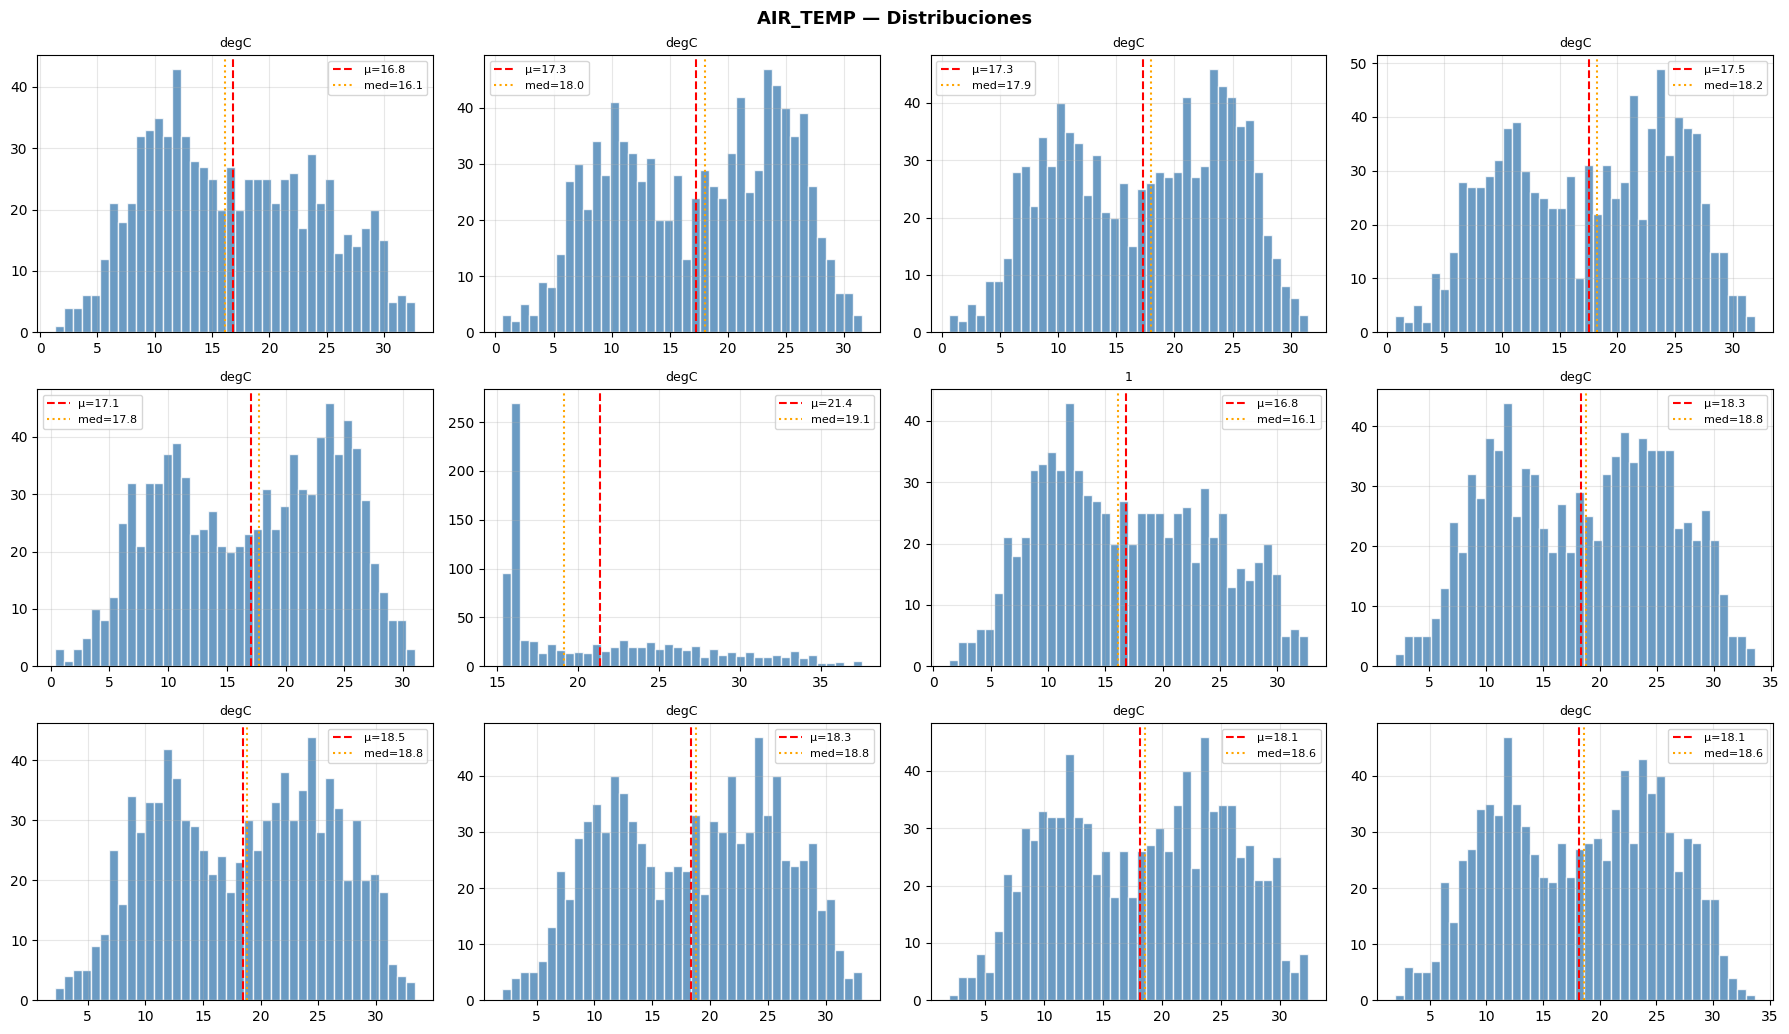

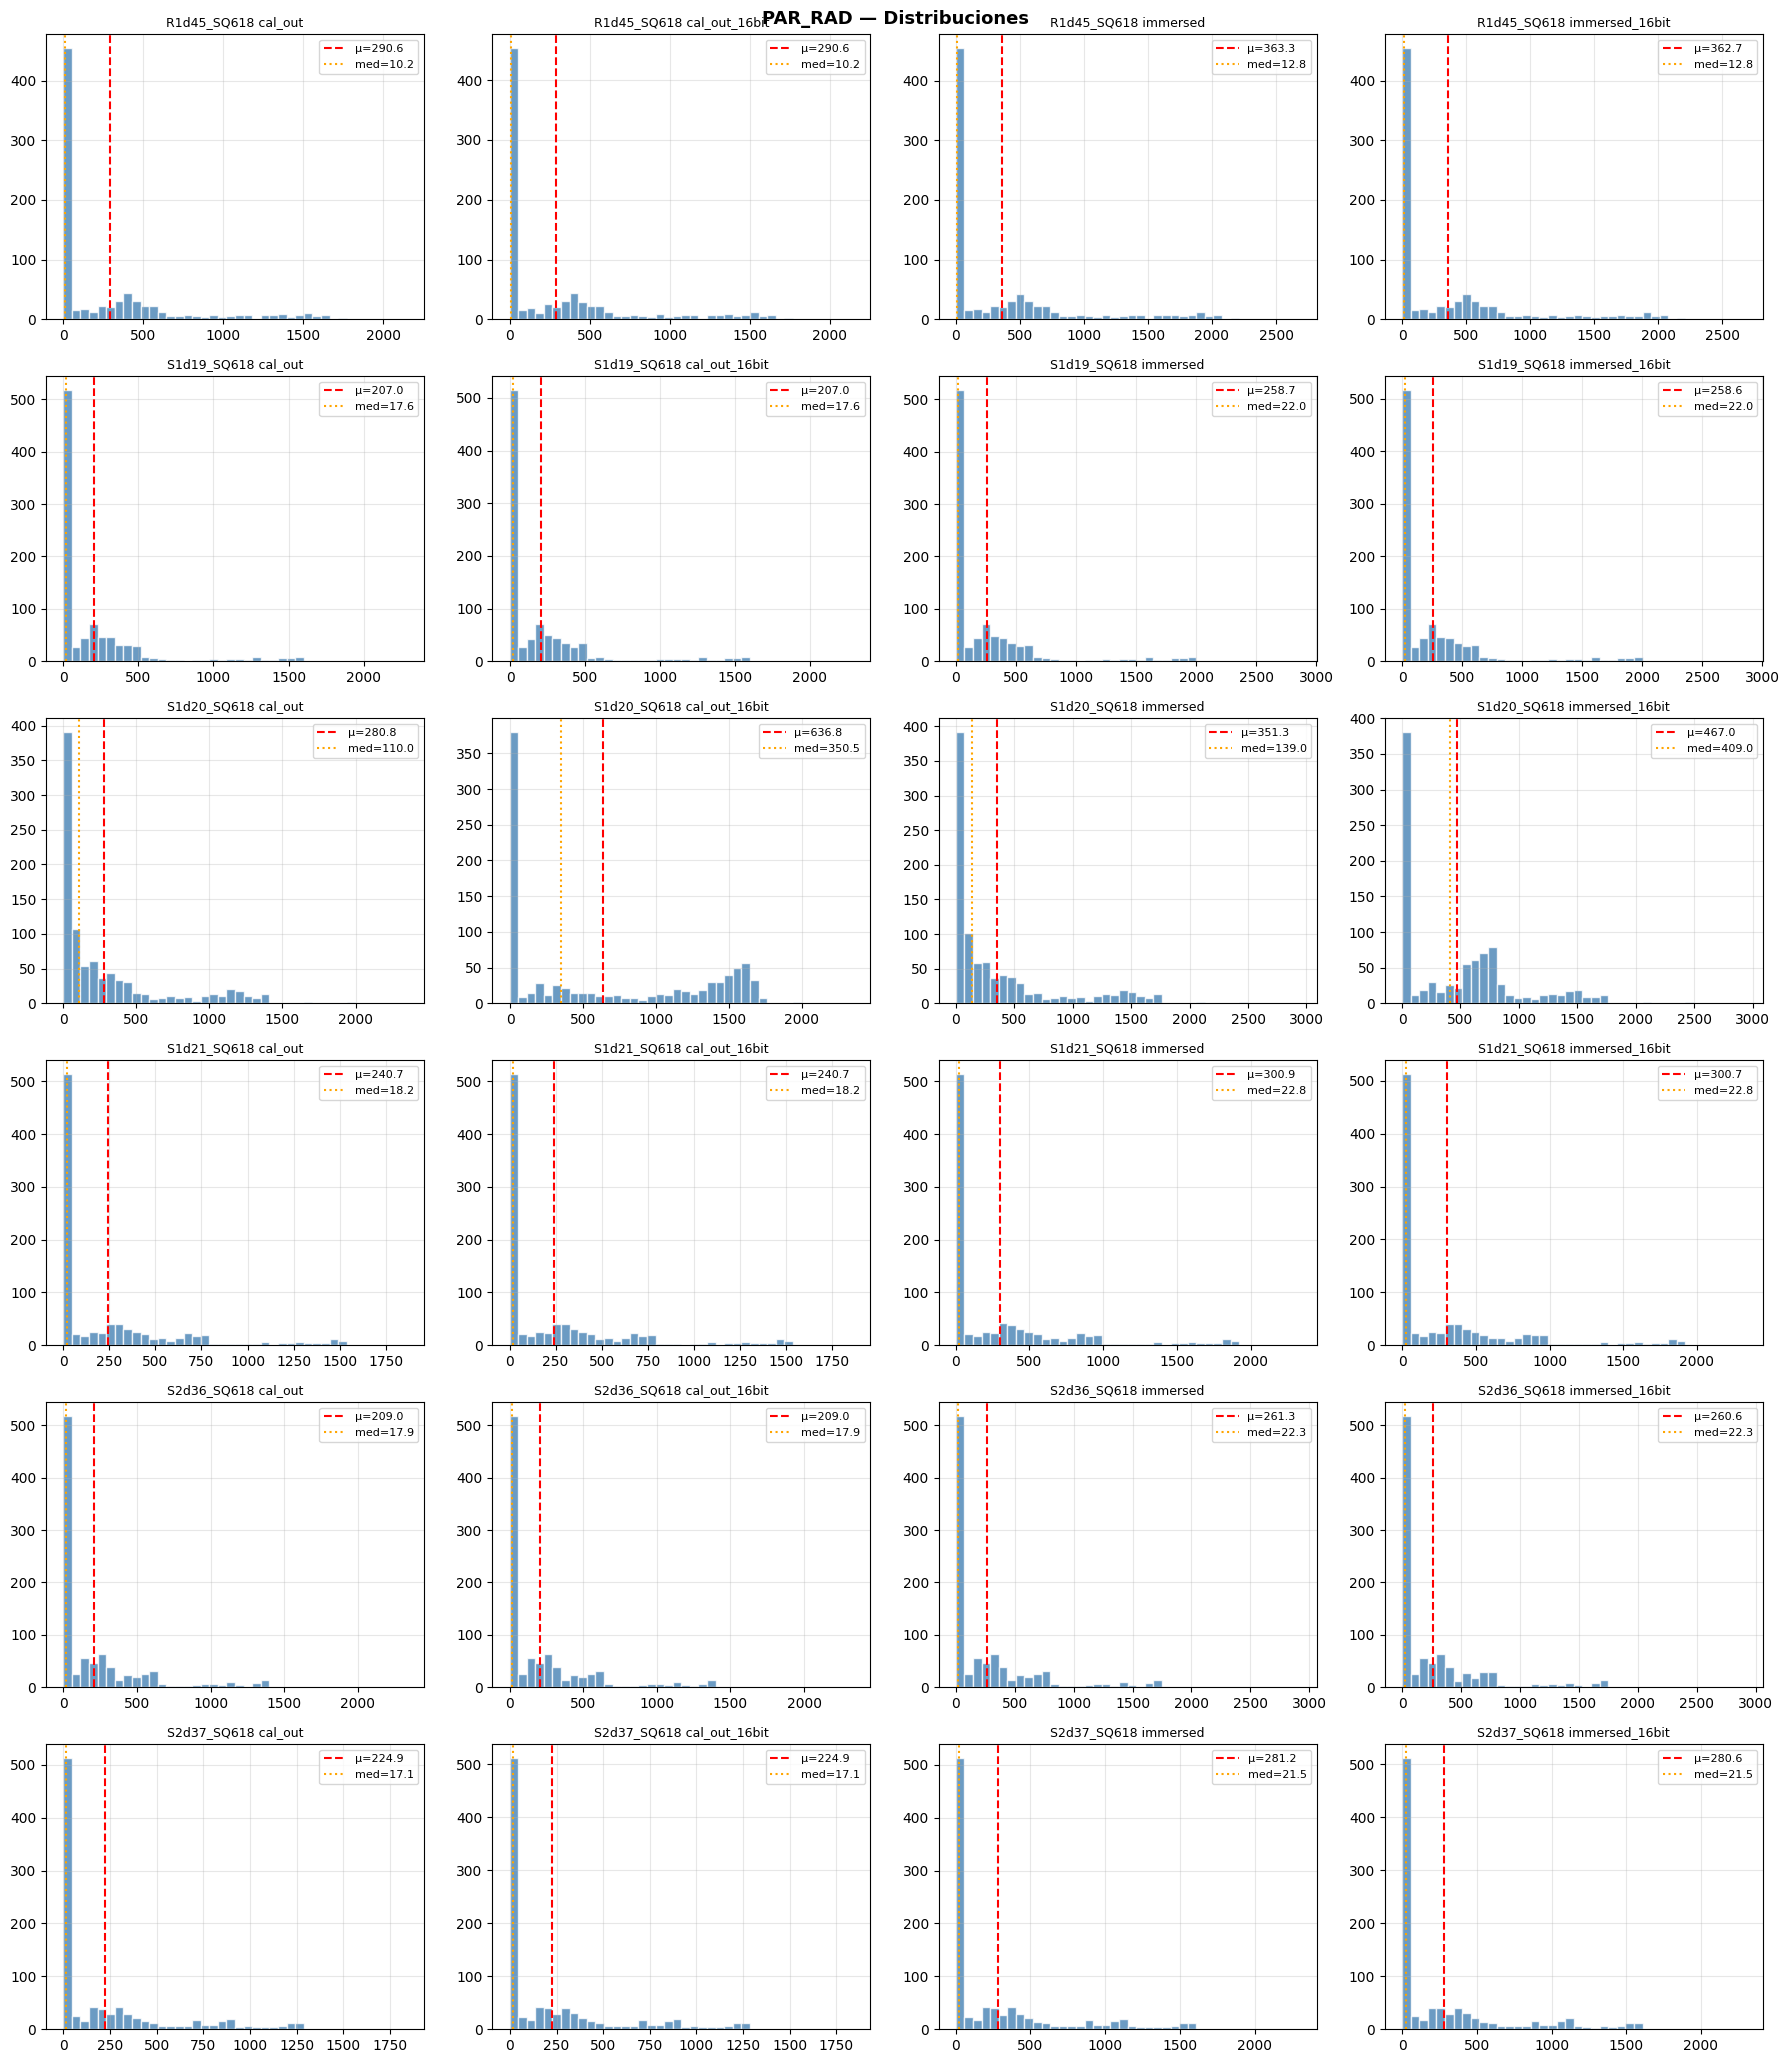

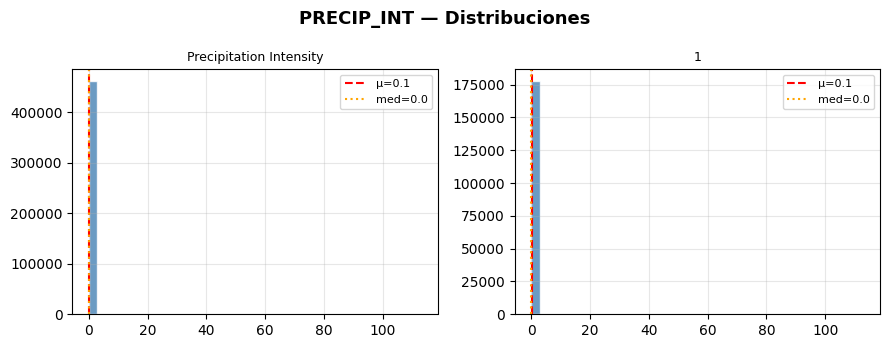

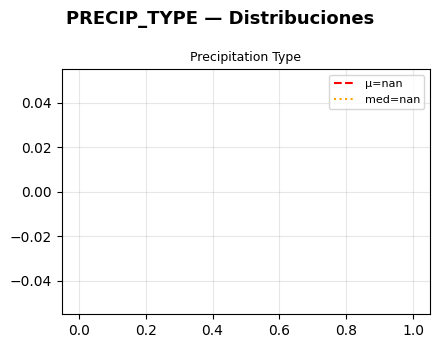

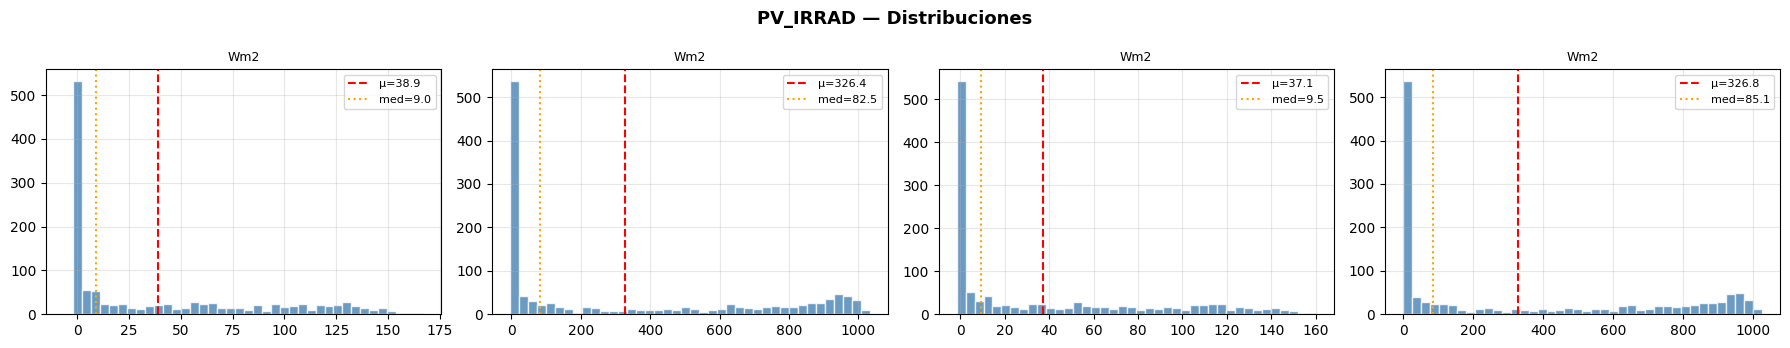

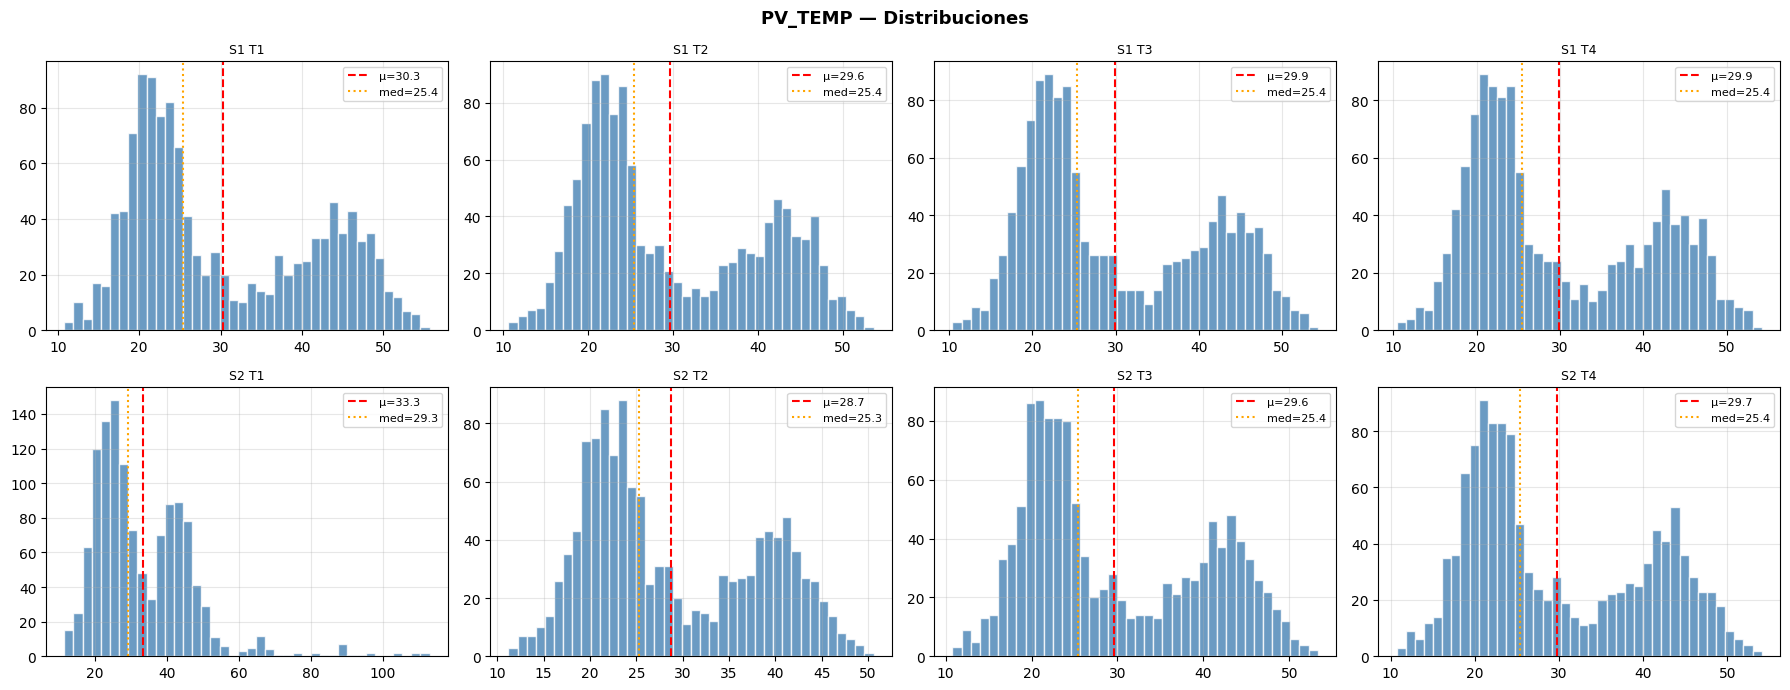

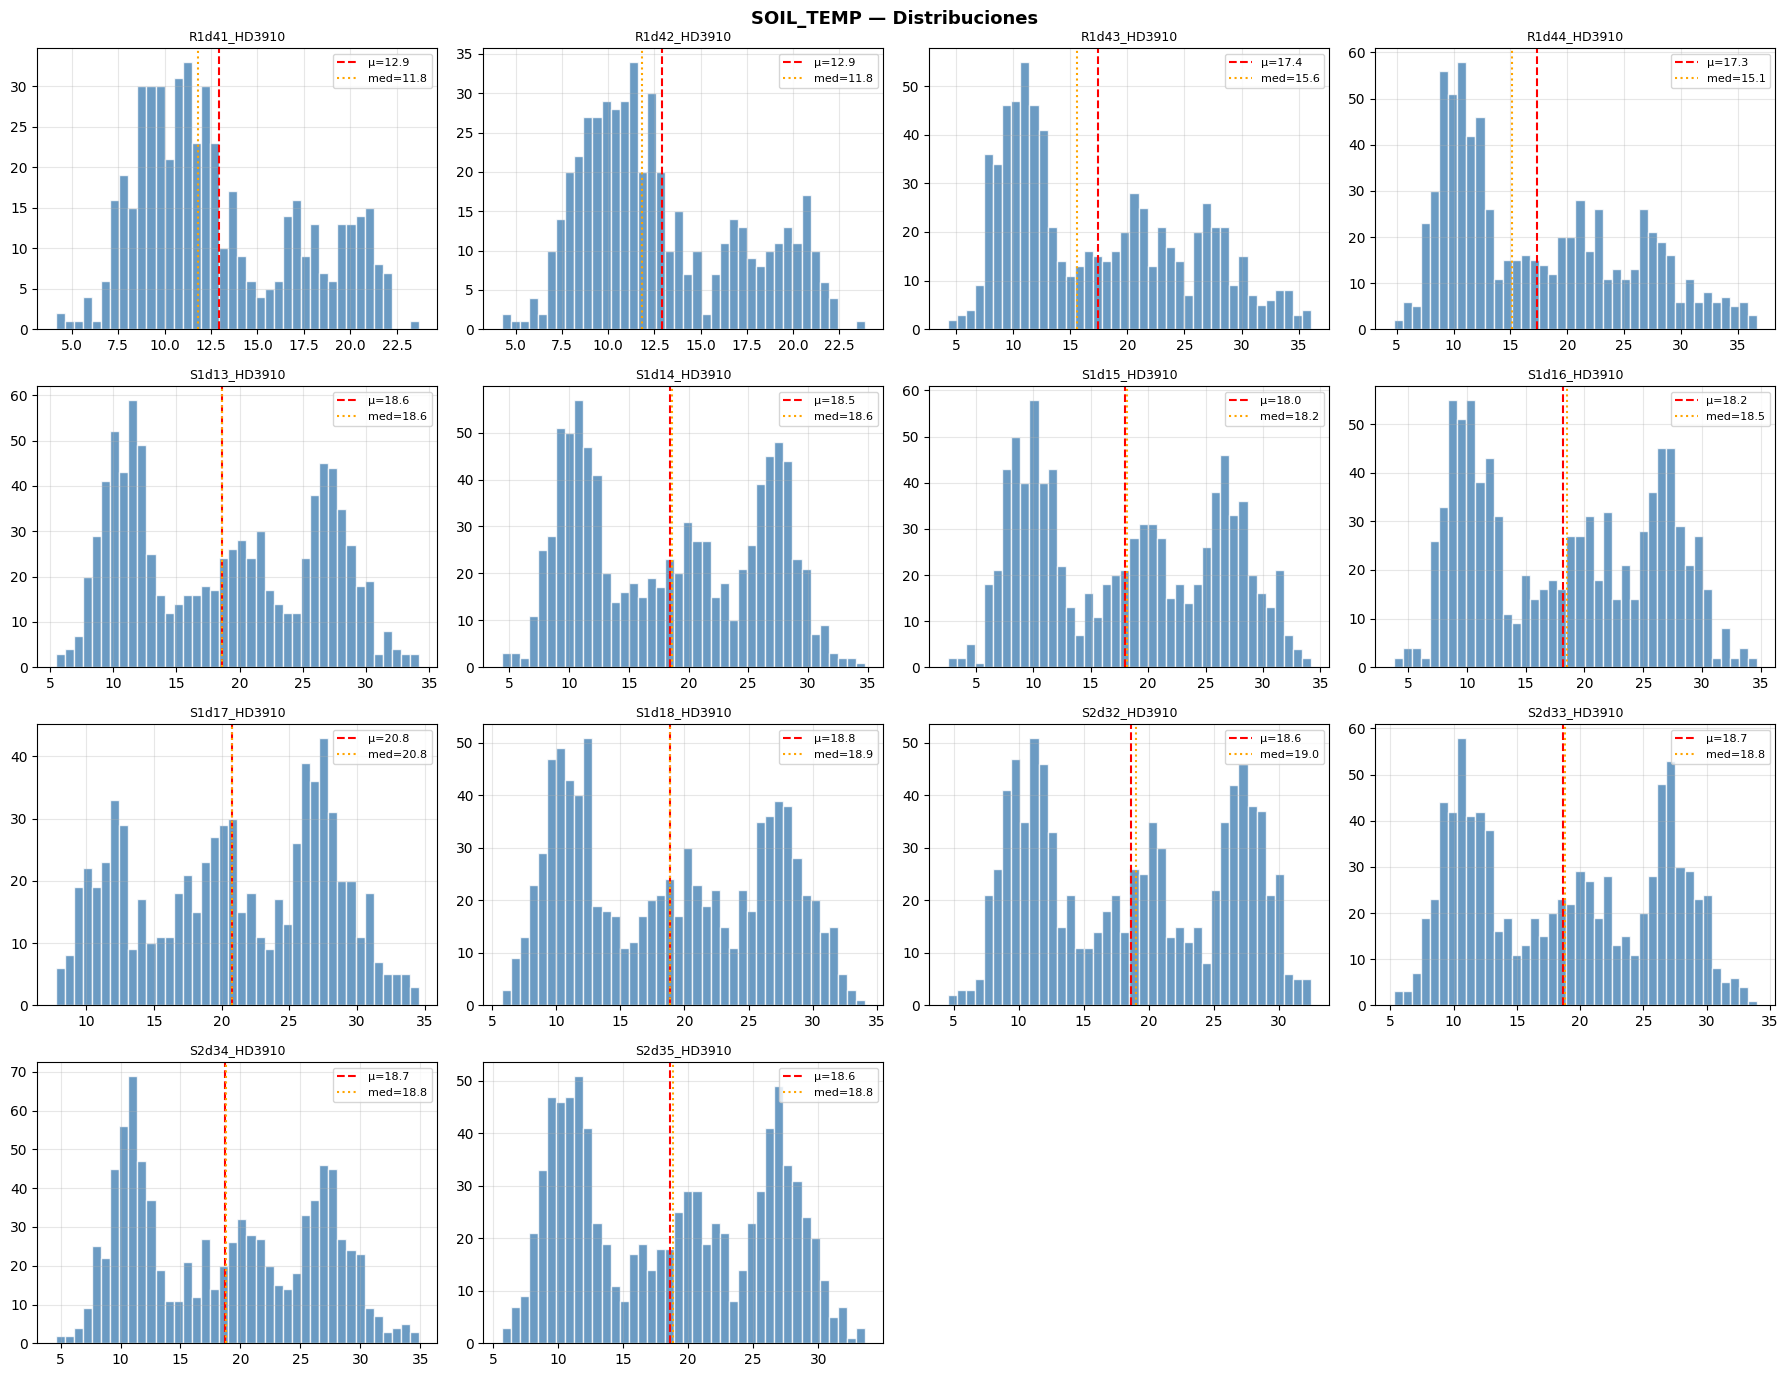

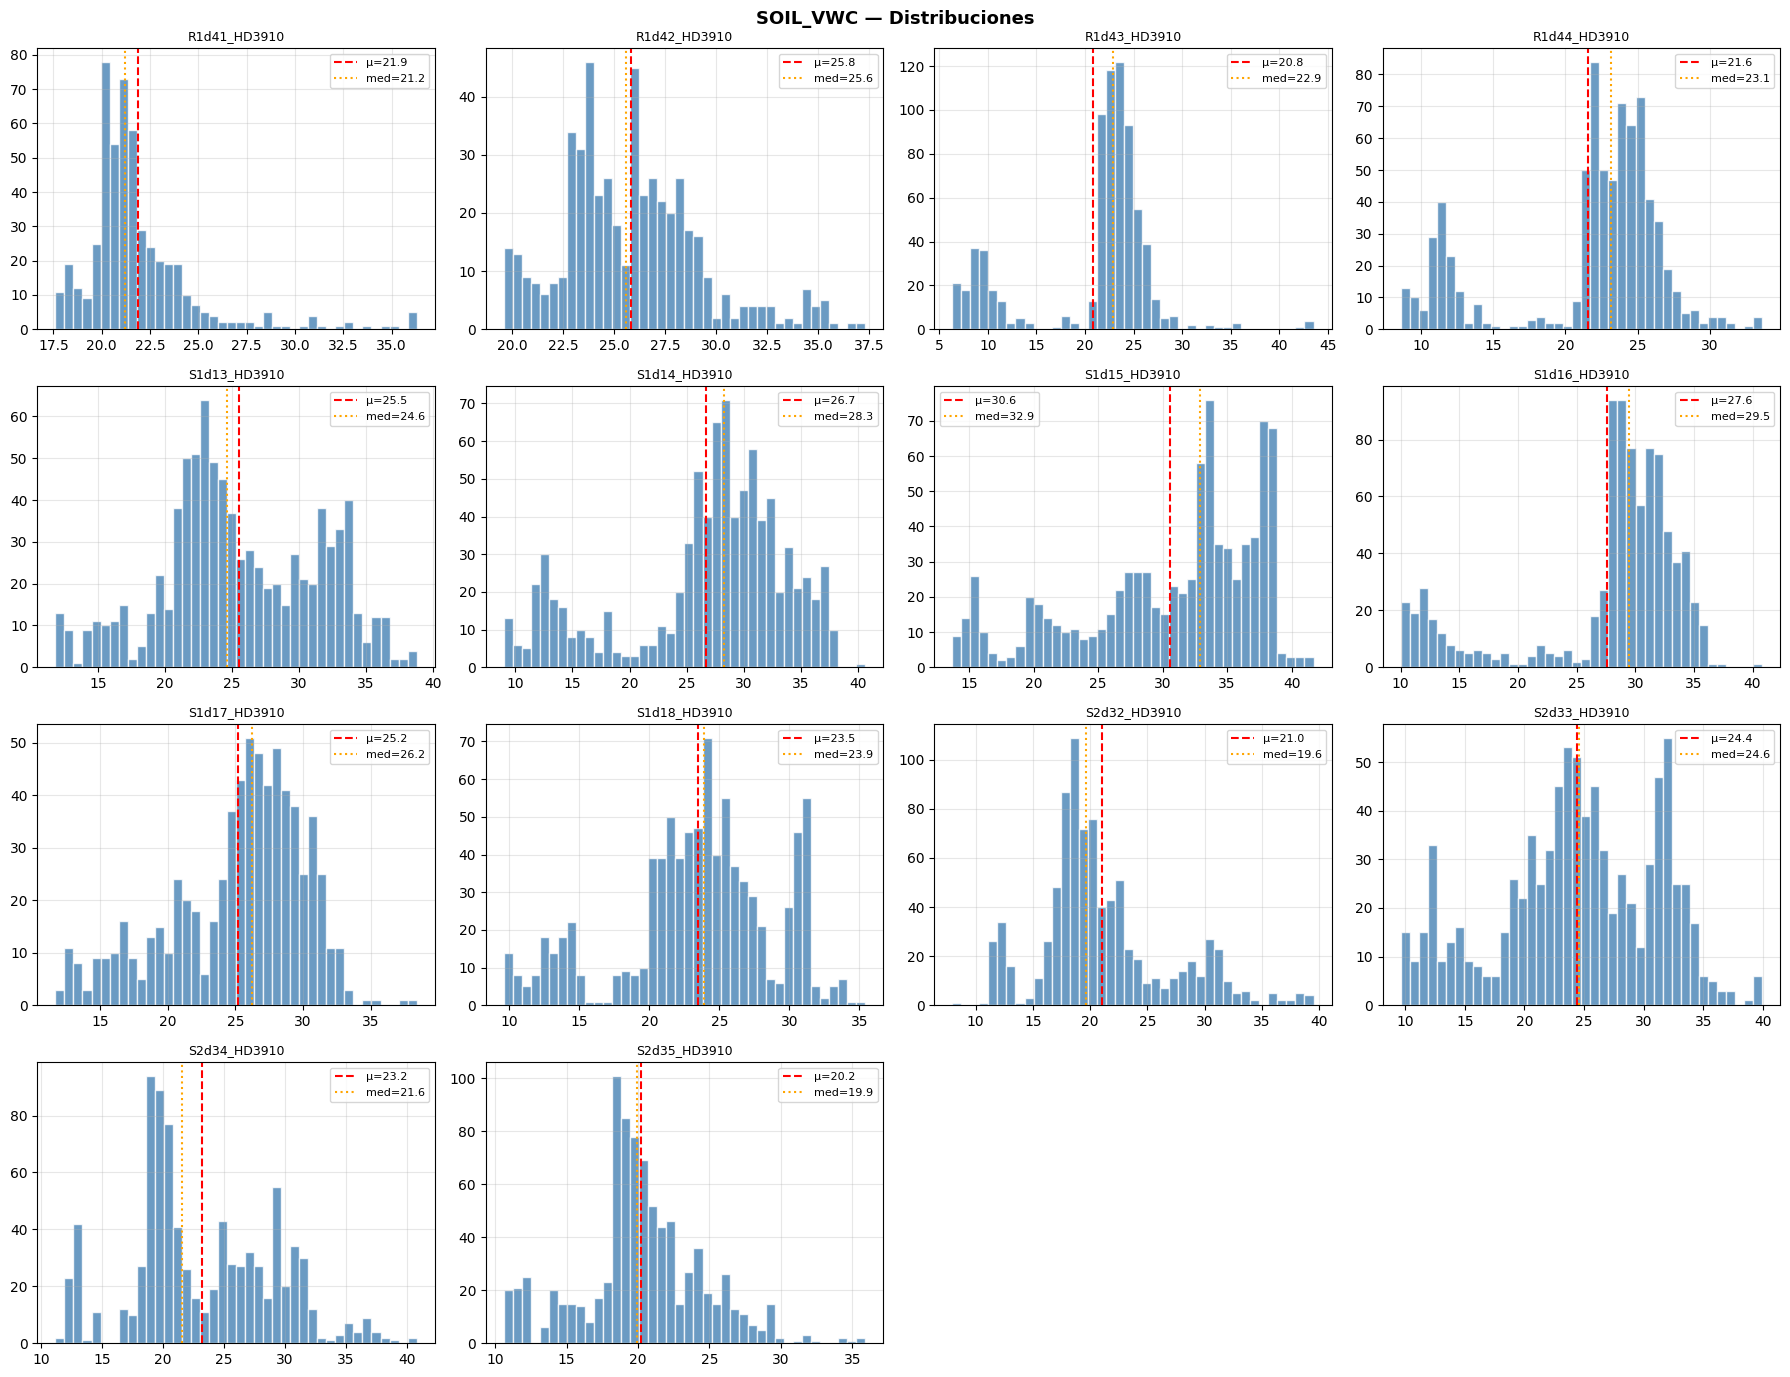

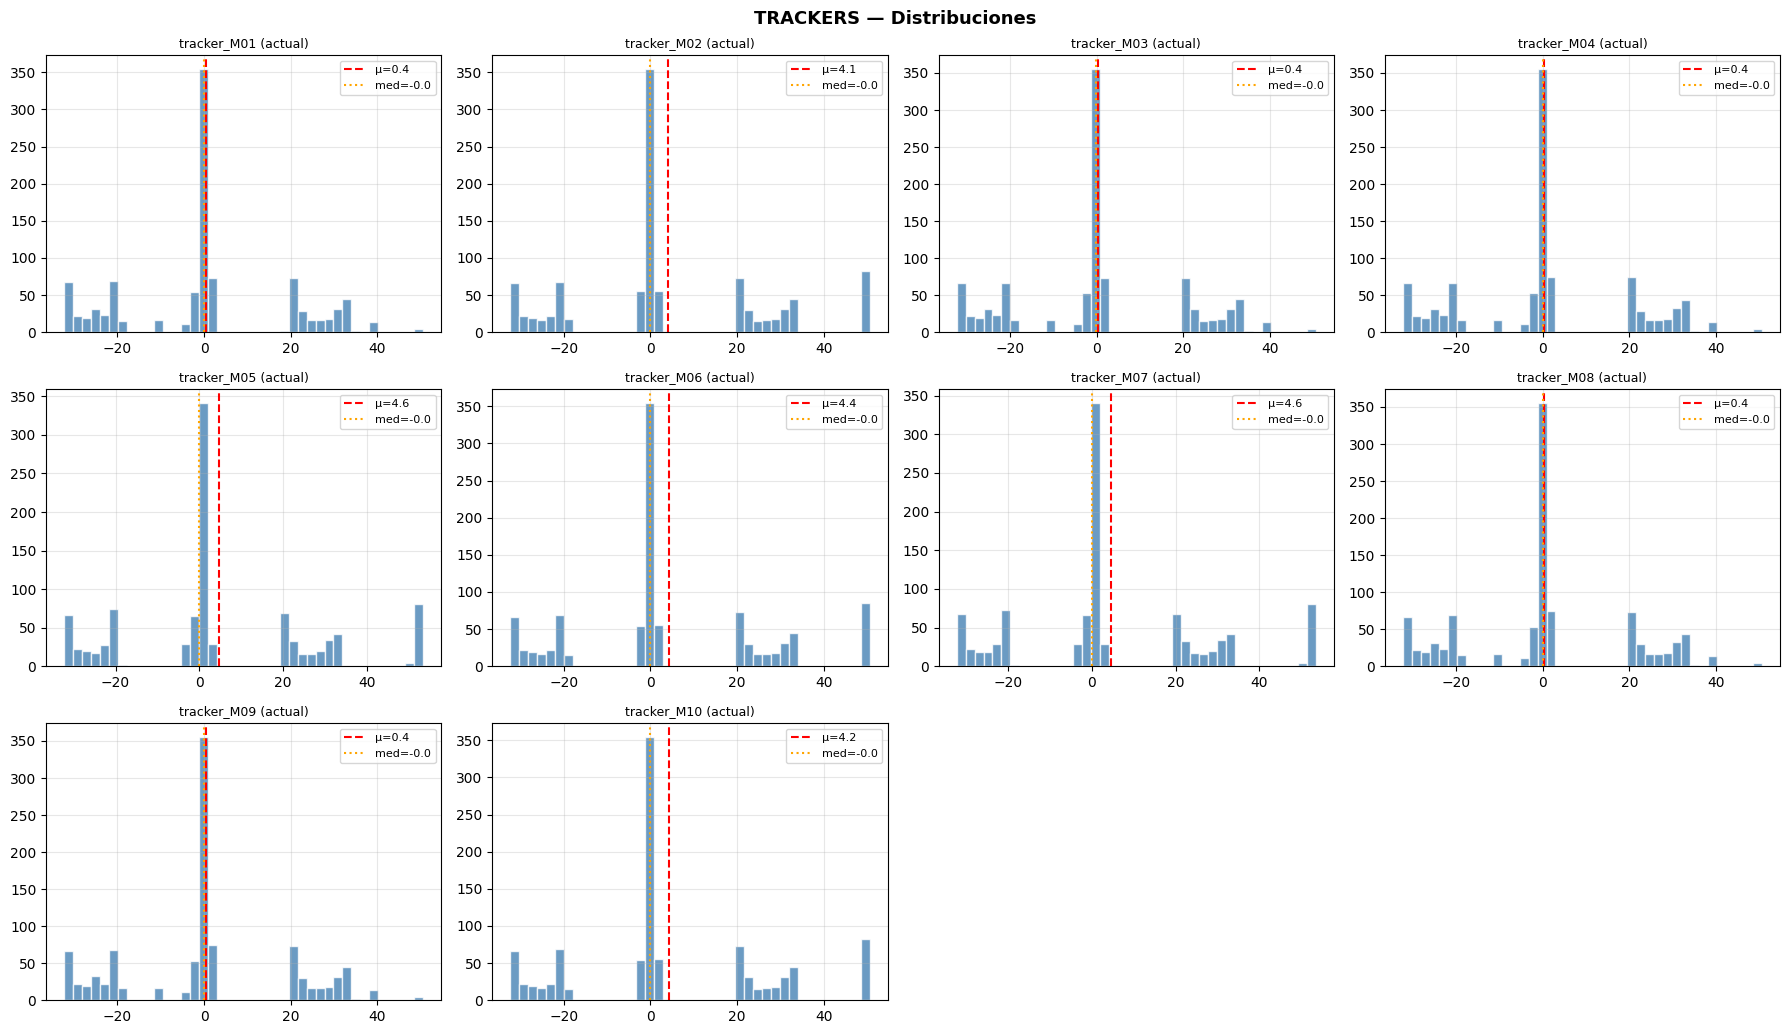

=> Distribuciones guardadas en outputs/


In [69]:
COLS_PER_ROW = 4  # ajusta segons preferència

for dsname, df_plot in dfs_num.items():
    num_cols = [c for c in df_plot.select_dtypes(include=np.number).columns if c != 'Time']
    if not num_cols:
        continue

    n = len(num_cols)
    ncols = min(n, COLS_PER_ROW)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows))
    axes = np.array(axes).flatten()  # sempre array 1D per iterar fàcil

    fig.suptitle(f'{dsname.upper()} — Distribuciones', fontweight='bold', fontsize=13)

    for ax, col in zip(axes, num_cols):
        s = df_plot[col].dropna()
        ax.hist(s, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
        ax.axvline(s.mean(),   color='red',    linestyle='--', label=f'μ={s.mean():.1f}')
        ax.axvline(s.median(), color='orange', linestyle=':',  label=f'med={s.median():.1f}')
        ax.set_title(col.split('.')[-1][:30], fontsize=9)
        ax.legend(fontsize=8)

    # Amagar eixos sobrants si n no és múltiple de COLS_PER_ROW
    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(OUT_DIR / f'dist_{dsname}.png', dpi=110, bbox_inches='tight')
    plt.show()

print('=> Distribuciones guardadas en outputs/')

In [70]:
def count_outliers_iqr(series: pd.Series, factor: float = 3.0) -> int:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return int(((series < q1 - factor * iqr) | (series > q3 + factor * iqr)).sum())


outlier_rows = []
for dsname, df_plot in dfs_num.items():
    num_cols = [c for c in df_plot.select_dtypes(include=np.number).columns if c != 'Time']
    for col in num_cols:
        s = df_plot[col].dropna()
        if len(s) < 10:
            continue
        n_out = count_outliers_iqr(s)
        outlier_rows.append({
            'Dataset':          dsname,
            'Variable':         col,
            'N válidos':        len(s),
            'Outliers (IQR×3)': n_out,
            'Outlier %':        round(n_out / len(s) * 100, 1),
            'Min':              round(s.min(), 2),
            'Max':              round(s.max(), 2),
            'Media':            round(s.mean(), 2),
        })

out_df = pd.DataFrame(outlier_rows)
display(out_df.sort_values('Outlier %', ascending=False))
out_df.to_csv(OUT_DIR / 'outliers_summary.csv', index=False)

,Dataset,Variable,N válidos,Outliers (IQR×3),Outlier %,Min,Max,Media
66,soil_vwc,R1d43_HD3910,741,156,21.100,6.340,43.500,20.840
71,soil_vwc,S1d16_HD3910,857,113,13.200,10.000,40.800,27.560
36,precip_int,Precipitation Intensity,464230,30981,6.700,0.000,113.000,0.090
18,par_rad,S1d19_SQ618 immersed,938,49,5.200,-0.050,2860.000,258.740
17,par_rad,S1d19_SQ618 cal_out_16bit,938,49,5.200,-4.010,2288.000,206.980
...,...,...,...,...,...,...,...,...
83,trackers,tracker_M06 (actual),1016,0,0.000,-32.300,50.600,4.370
84,trackers,tracker_M07 (actual),1016,0,0.000,-32.300,53.500,4.600
85,trackers,tracker_M08 (actual),1016,0,0.000,-32.300,50.600,0.350
86,trackers,tracker_M09 (actual),1016,0,0.000,-32.300,50.600,0.350


# ANALISI

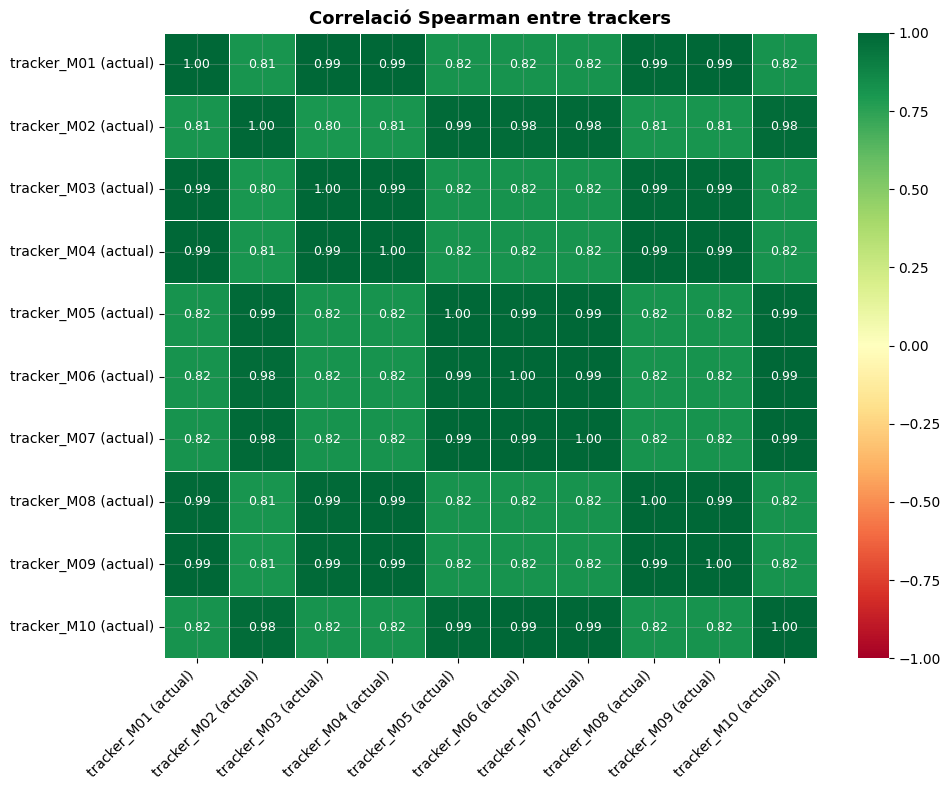

Parelles amb Spearman r > 0.95:
  tracker_M01 (actual)           ↔ tracker_M03 (actual)            r=0.995
  tracker_M01 (actual)           ↔ tracker_M04 (actual)            r=0.994
  tracker_M01 (actual)           ↔ tracker_M08 (actual)            r=0.991
  tracker_M01 (actual)           ↔ tracker_M09 (actual)            r=0.992
  tracker_M02 (actual)           ↔ tracker_M05 (actual)            r=0.985
  tracker_M02 (actual)           ↔ tracker_M06 (actual)            r=0.981
  tracker_M02 (actual)           ↔ tracker_M07 (actual)            r=0.984
  tracker_M02 (actual)           ↔ tracker_M10 (actual)            r=0.982
  tracker_M03 (actual)           ↔ tracker_M04 (actual)            r=0.995
  tracker_M03 (actual)           ↔ tracker_M08 (actual)            r=0.992
  tracker_M03 (actual)           ↔ tracker_M09 (actual)            r=0.992
  tracker_M04 (actual)           ↔ tracker_M08 (actual)            r=0.993
  tracker_M04 (actual)           ↔ tracker_M09 (actual)            r

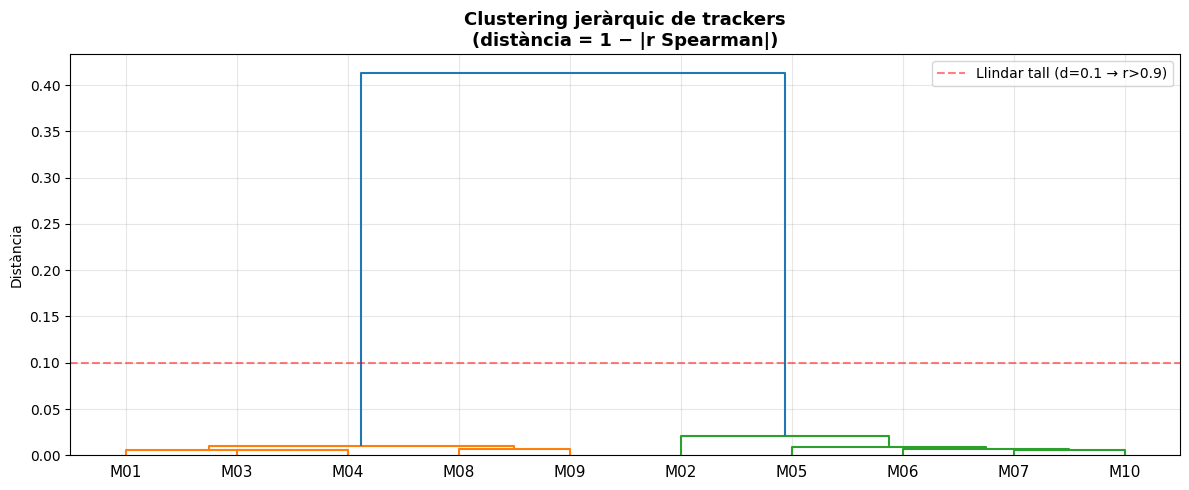


Grups de trackers detectats:


,Tracker,Grup
0,M01,1
2,M03,1
3,M04,1
7,M08,1
8,M09,1
1,M02,2
5,M06,2
4,M05,2
6,M07,2
9,M10,2



Contrast amb nomenclatura de sensors:
  Sensors S1dXX → secció S1  (esperem que coincideixi amb un grup)
  Sensors S2dXX → secció S2  (esperem que coincideixi amb l'altre grup)
  Grup 1: ['M01', 'M03', 'M04', 'M08', 'M09']
  Grup 2: ['M02', 'M06', 'M05', 'M07', 'M10']

=> Guardat en outputs/tracker_groups.csv

Variança de l'angle per tracker (baixa variança = possible stow fix o avaria):


,Variança (°²)
M04,365.970
M01,366.090
M03,366.200
M09,366.280
M08,366.360
M02,508.520
M10,508.980
M06,513.010
M05,534.870
M07,535.000


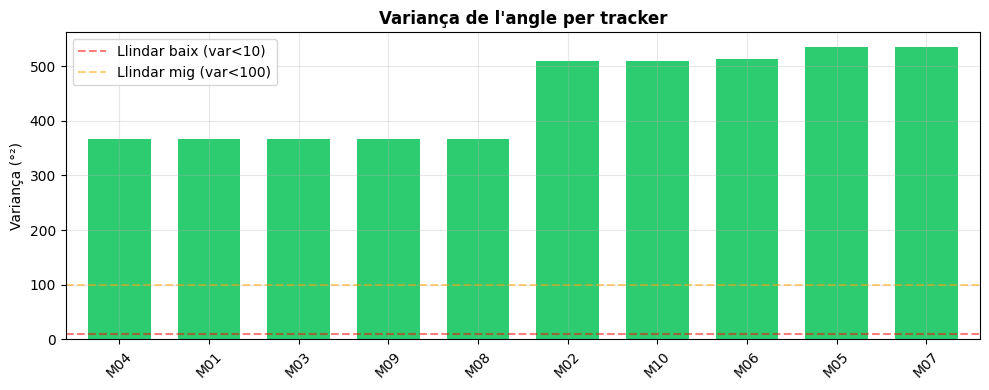

In [78]:
# ── Anàlisi de trackers ──────────────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

df_track = dfs_num['trackers'].copy()
tracker_cols = [c for c in df_track.select_dtypes(include=np.number).columns if c != 'Time']

# ── 1. Matriu de correlació Spearman ────────────────────────────────────────
corr_trackers = df_track[tracker_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_trackers, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0, linewidths=0.5,
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Correlació Spearman entre trackers', fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'tracker_corr_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 2. Grups amb r > 0.95 ───────────────────────────────────────────────────
print('Parelles amb Spearman r > 0.95:')
for i in range(len(tracker_cols)):
    for j in range(i + 1, len(tracker_cols)):
        r = corr_trackers.iloc[i, j]
        if r > 0.95:
            print(f'  {tracker_cols[i]:30s} ↔ {tracker_cols[j]:30s}  r={r:.3f}')

# ── 3. Dendrograma de clustering jeràrquic ──────────────────────────────────
# Convertim correlació a distància: d = 1 - r
dist_matrix = (1 - corr_trackers.abs()).to_numpy().copy()  
np.fill_diagonal(dist_matrix, 0)
dist_condensed = squareform(dist_matrix)

linkage_matrix = linkage(dist_condensed, method='ward')

# Escurçar els noms per llegibilitat
short_names = [c.replace('tracker_', '').replace(' (actual)', '') for c in tracker_cols]

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    labels=short_names,
    ax=ax,
    color_threshold=0.1,
    leaf_font_size=11,
)
ax.set_title('Clustering jeràrquic de trackers\n(distància = 1 − |r Spearman|)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Distància')
ax.axhline(0.1, color='red', linestyle='--', alpha=0.5, label='Llindar tall (d=0.1 → r>0.9)')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'tracker_dendrogram.png', dpi=120, bbox_inches='tight')
plt.show()

# ── 4. Assignació grups → seccions ──────────────────────────────────────────
# Tallem l'arbre a distància 0.1 (equivalent a r > 0.9) per obtenir grups
from scipy.cluster.hierarchy import fcluster

labels_cluster = fcluster(linkage_matrix, t=0.1, criterion='distance')
cluster_df = pd.DataFrame({
    'Tracker':  short_names,
    'Grup':     labels_cluster
}).sort_values('Grup')

print('\nGrups de trackers detectats:')
display(cluster_df)

print('\nContrast amb nomenclatura de sensors:')
print('  Sensors S1dXX → secció S1  (esperem que coincideixi amb un grup)')
print('  Sensors S2dXX → secció S2  (esperem que coincideixi amb l\'altre grup)')
for g in sorted(cluster_df['Grup'].unique()):
    membres = cluster_df[cluster_df['Grup'] == g]['Tracker'].tolist()
    print(f'  Grup {g}: {membres}')

cluster_df.to_csv(OUT_DIR / 'tracker_groups.csv', index=False)
print('\n=> Guardat en outputs/tracker_groups.csv')

# ── 5. Variança per tracker (detectar trackers fixos / avariats) ─────────────
print('\nVariança de l\'angle per tracker (baixa variança = possible stow fix o avaria):')
tracker_var = df_track[tracker_cols].var().sort_values()
tracker_var.index = [c.replace('tracker_', '').replace(' (actual)', '') for c in tracker_var.index]
display(tracker_var.to_frame('Variança (°²)').round(2))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#e74c3c' if v < 10 else '#f39c12' if v < 100 else '#2ecc71'
          for v in tracker_var.values]
tracker_var.plot(kind='bar', ax=ax, color=colors, width=0.7)
ax.axhline(10,  color='red',    linestyle='--', alpha=0.5, label='Llindar baix (var<10)')
ax.axhline(100, color='orange', linestyle='--', alpha=0.5, label='Llindar mig (var<100)')
ax.set_title('Variança de l\'angle per tracker', fontweight='bold')
ax.set_ylabel('Variança (°²)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'tracker_variance.png', dpi=120, bbox_inches='tight')
plt.show()

In [79]:
# ── Efecte sobre radiació i sòl ──────────────────────────────────────────────

# ── 0. Construir dataset integrat a 6h ──────────────────────────────────────
def resample_to_6h(df_num: pd.DataFrame) -> pd.DataFrame:
    df = df_num.copy().set_index('Time').sort_index()
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    return df[num_cols].resample('6h').mean()

# Selecció de columnes representatives per cada dataset
# Ajusta els noms si no coincideixen exactament amb els teus CSVs
COL_MAP = {
    'air_temp':  {'WS100.Air.TempAvg.degC': 'Tair_WS'},
    'pv_irrad':  {
        'S1d12_Z8AI.pyra.GPOA.Wm2':  'GPOA_S1',
        'S2d30_Z8AI.pyra.GPOA.Wm2':  'GPOA_S2',
    },
    'par_rad': {
        'S1d19_SQ618 cal_out': 'ePAR_S1d19',
        'S1d20_SQ618 cal_out': 'ePAR_S1d20',
        'S2d36_SQ618 cal_out': 'ePAR_S2d36',
        'S2d37_SQ618 cal_out': 'ePAR_S2d37',
    },
    'soil_temp': {
        'S1d13_HD3910': 'Tsoil_S1d13',
        'S1d14_HD3910': 'Tsoil_S1d14',
        'S2d32_HD3910': 'Tsoil_S2d32',
    },
    'soil_vwc': {
        'S1d13_HD3910': 'VWC_S1d13',
        'S1d14_HD3910': 'VWC_S1d14',
        'S2d32_HD3910': 'VWC_S2d32',
    },
    'trackers': {
        'tracker_M01 (actual)': 'track_M01',
        'tracker_M03 (actual)': 'track_M03',
        'tracker_M05 (actual)': 'track_M05',
    },
}

merged_parts = []
for dsname, col_map in COL_MAP.items():
    df_r = resample_to_6h(dfs_num[dsname])
    valid = {k: v for k, v in col_map.items() if k in df_r.columns}
    if valid:
        merged_parts.append(df_r[list(valid.keys())].rename(columns=valid))

df = pd.concat(merged_parts, axis=1)
print(f'Dataset integrat: {df.shape[0]} timesteps × {df.shape[1]} variables')
print(f'Nuls promedio: {df.isnull().mean().mean()*100:.1f}%')
print(f'Columnes disponibles: {df.columns.tolist()}')

Dataset integrat: 1462 timesteps × 16 variables
Nuls promedio: 40.8%
Columnes disponibles: ['Tair_WS', 'GPOA_S1', 'GPOA_S2', 'ePAR_S1d19', 'ePAR_S1d20', 'ePAR_S2d36', 'ePAR_S2d37', 'Tsoil_S1d13', 'Tsoil_S1d14', 'Tsoil_S2d32', 'VWC_S1d13', 'VWC_S1d14', 'VWC_S2d32', 'track_M01', 'track_M03', 'track_M05']


Fracció transmesa (ePAR / GPOA_ref) — estadística:


,frac_ePAR_S1d19,frac_ePAR_S1d20,frac_ePAR_S2d36,frac_ePAR_S2d37
count,415.000,415.000,415.000,415.000
mean,-0.356,-0.201,-0.586,-0.407
std,3.580,3.483,4.186,3.457
min,-14.479,-12.877,-18.395,-14.380
25%,-0.000,-0.000,-0.000,-0.000
50%,0.054,0.063,0.051,0.057
75%,0.522,1.260,0.688,1.285
max,9.652,11.276,9.507,9.652


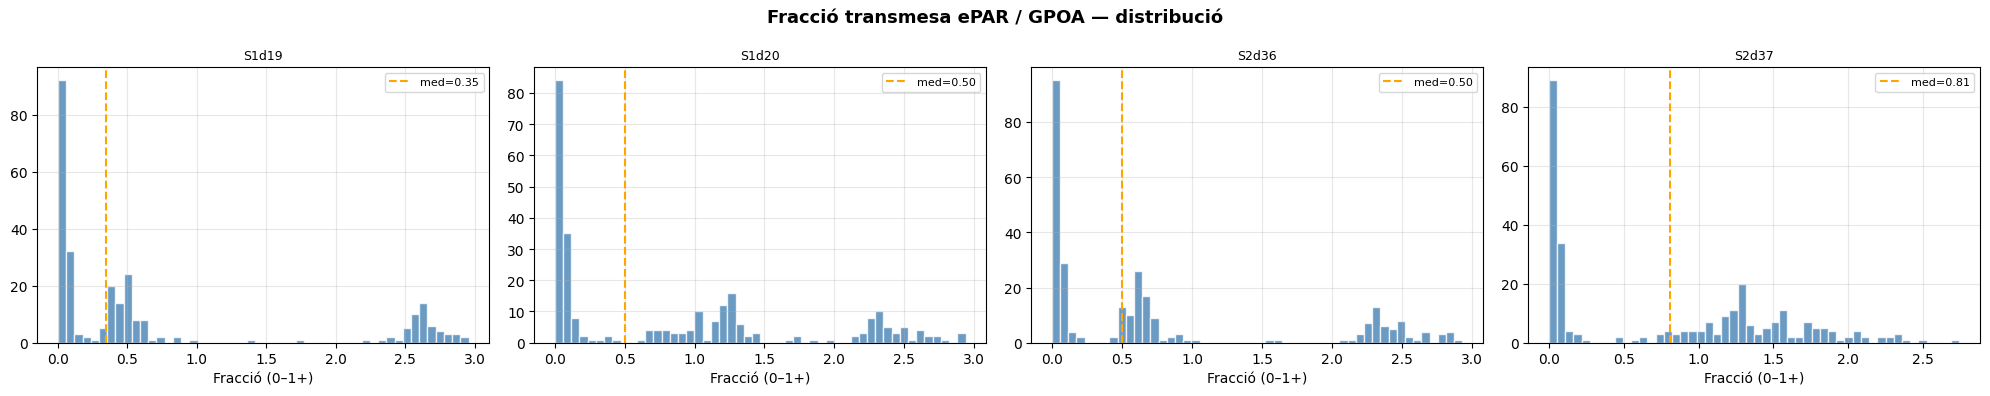

In [80]:
# ── 1. Fracció transmesa: ePAR_interior / GPOA_WS100 ────────────────────────
# WS100 no té piranòmetre directe als teus dades — usem GPOA_S1 com a proxy
# de referència de cel obert (panel en posició horitzontal = màxima transmissió)
# Si tens una columna de GHI exterior, substitueix-la aquí.

epar_cols = [c for c in df.columns if c.startswith('ePAR')]
gpoa_ref  = 'GPOA_S1' if 'GPOA_S1' in df.columns else None

if gpoa_ref and epar_cols:
    for epar_col in epar_cols:
        frac_col = f'frac_{epar_col}'
        df[frac_col] = df[epar_col] / df[gpoa_ref].replace(0, np.nan)

    frac_cols = [c for c in df.columns if c.startswith('frac_')]
    print('Fracció transmesa (ePAR / GPOA_ref) — estadística:')
    display(df[frac_cols].describe().round(3))

    fig, axes = plt.subplots(1, len(frac_cols), figsize=(5 * len(frac_cols), 4))
    if len(frac_cols) == 1:
        axes = [axes]
    fig.suptitle('Fracció transmesa ePAR / GPOA — distribució', fontweight='bold', fontsize=13)
    for ax, col in zip(axes, frac_cols):
        s = df[col].dropna()
        s = s[(s >= 0) & (s <= 3)]   # filtrem valors físicament impossibles
        ax.hist(s, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
        ax.axvline(s.median(), color='orange', linestyle='--',
                   label=f'med={s.median():.2f}')
        ax.set_title(col.replace('frac_ePAR_', ''), fontsize=9)
        ax.set_xlabel('Fracció (0–1+)')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'frac_transmesa_dist.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('[WARN] No s\'han trobat columnes ePAR o GPOA_ref — revisa COL_MAP')

Distribució de règims:


,N timesteps
regime,
HORIZONTAL,494
DESCONOCIDO,446
TRACKING_AM,266
TRACKING_PM,252
STOW,4


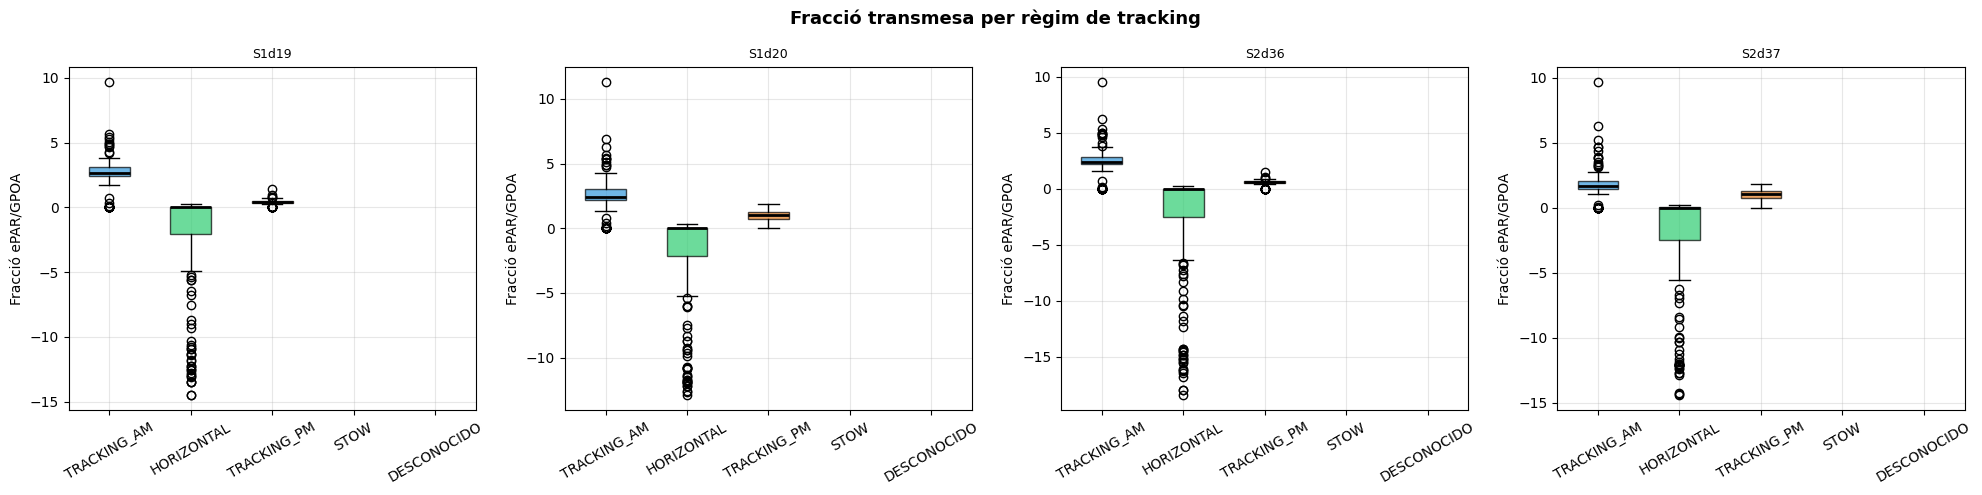


Mediana de fracció transmesa per règim:


,frac_ePAR_S1d19,frac_ePAR_S1d20,frac_ePAR_S2d36,frac_ePAR_S2d37
regime,,,,
DESCONOCIDO,NaN,NaN,NaN,NaN
HORIZONTAL,-0.000,-0.000,-0.000,-0.000
STOW,NaN,NaN,NaN,NaN
TRACKING_AM,2.629,2.414,2.373,1.714
TRACKING_PM,0.451,1.031,0.609,1.092


In [81]:
# ── 2. Règim de tracking i fracció transmesa ────────────────────────────────
STOW_ANGLE = 50.6
STOW_TOL   = 0.5

def classify_regime(a):
    if pd.isna(a):       return 'DESCONOCIDO'
    if abs(a - STOW_ANGLE) < STOW_TOL: return 'STOW'
    elif abs(a) < 5:     return 'HORIZONTAL'
    elif a < 0:          return 'TRACKING_AM'
    else:                return 'TRACKING_PM'

if 'track_M01' in df.columns:
    df['regime'] = df['track_M01'].apply(classify_regime)
    print('Distribució de règims:')
    display(df['regime'].value_counts().to_frame('N timesteps'))

    if frac_cols:
        regime_order = ['TRACKING_AM', 'HORIZONTAL', 'TRACKING_PM', 'STOW', 'DESCONOCIDO']

        fig, axes = plt.subplots(1, len(frac_cols), figsize=(5 * len(frac_cols), 5))
        if len(frac_cols) == 1:
            axes = [axes]
        fig.suptitle('Fracció transmesa per règim de tracking',
                     fontweight='bold', fontsize=13)

        for ax, col in zip(axes, frac_cols):
            data_reg = [
                df.loc[df['regime'] == r, col].dropna().values
                for r in regime_order
                if r in df['regime'].unique()
            ]
            labels_reg = [r for r in regime_order if r in df['regime'].unique()]
            bp = ax.boxplot(data_reg, labels=labels_reg, patch_artist=True,
                            medianprops=dict(color='black', linewidth=2))
            colors_reg = ['#3498db', '#2ecc71', '#e67e22', '#95a5a6', '#bdc3c7']
            for patch, color in zip(bp['boxes'], colors_reg):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_title(col.replace('frac_ePAR_', ''), fontsize=9)
            ax.set_ylabel('Fracció ePAR/GPOA')
            ax.tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.savefig(OUT_DIR / 'frac_per_regime.png', dpi=120, bbox_inches='tight')
        plt.show()

        # Taula resum: mediana de fracció per règim
        print('\nMediana de fracció transmesa per règim:')
        summary = df.groupby('regime')[frac_cols].median().round(3)
        display(summary)
        summary.to_csv(OUT_DIR / 'frac_per_regime.csv')

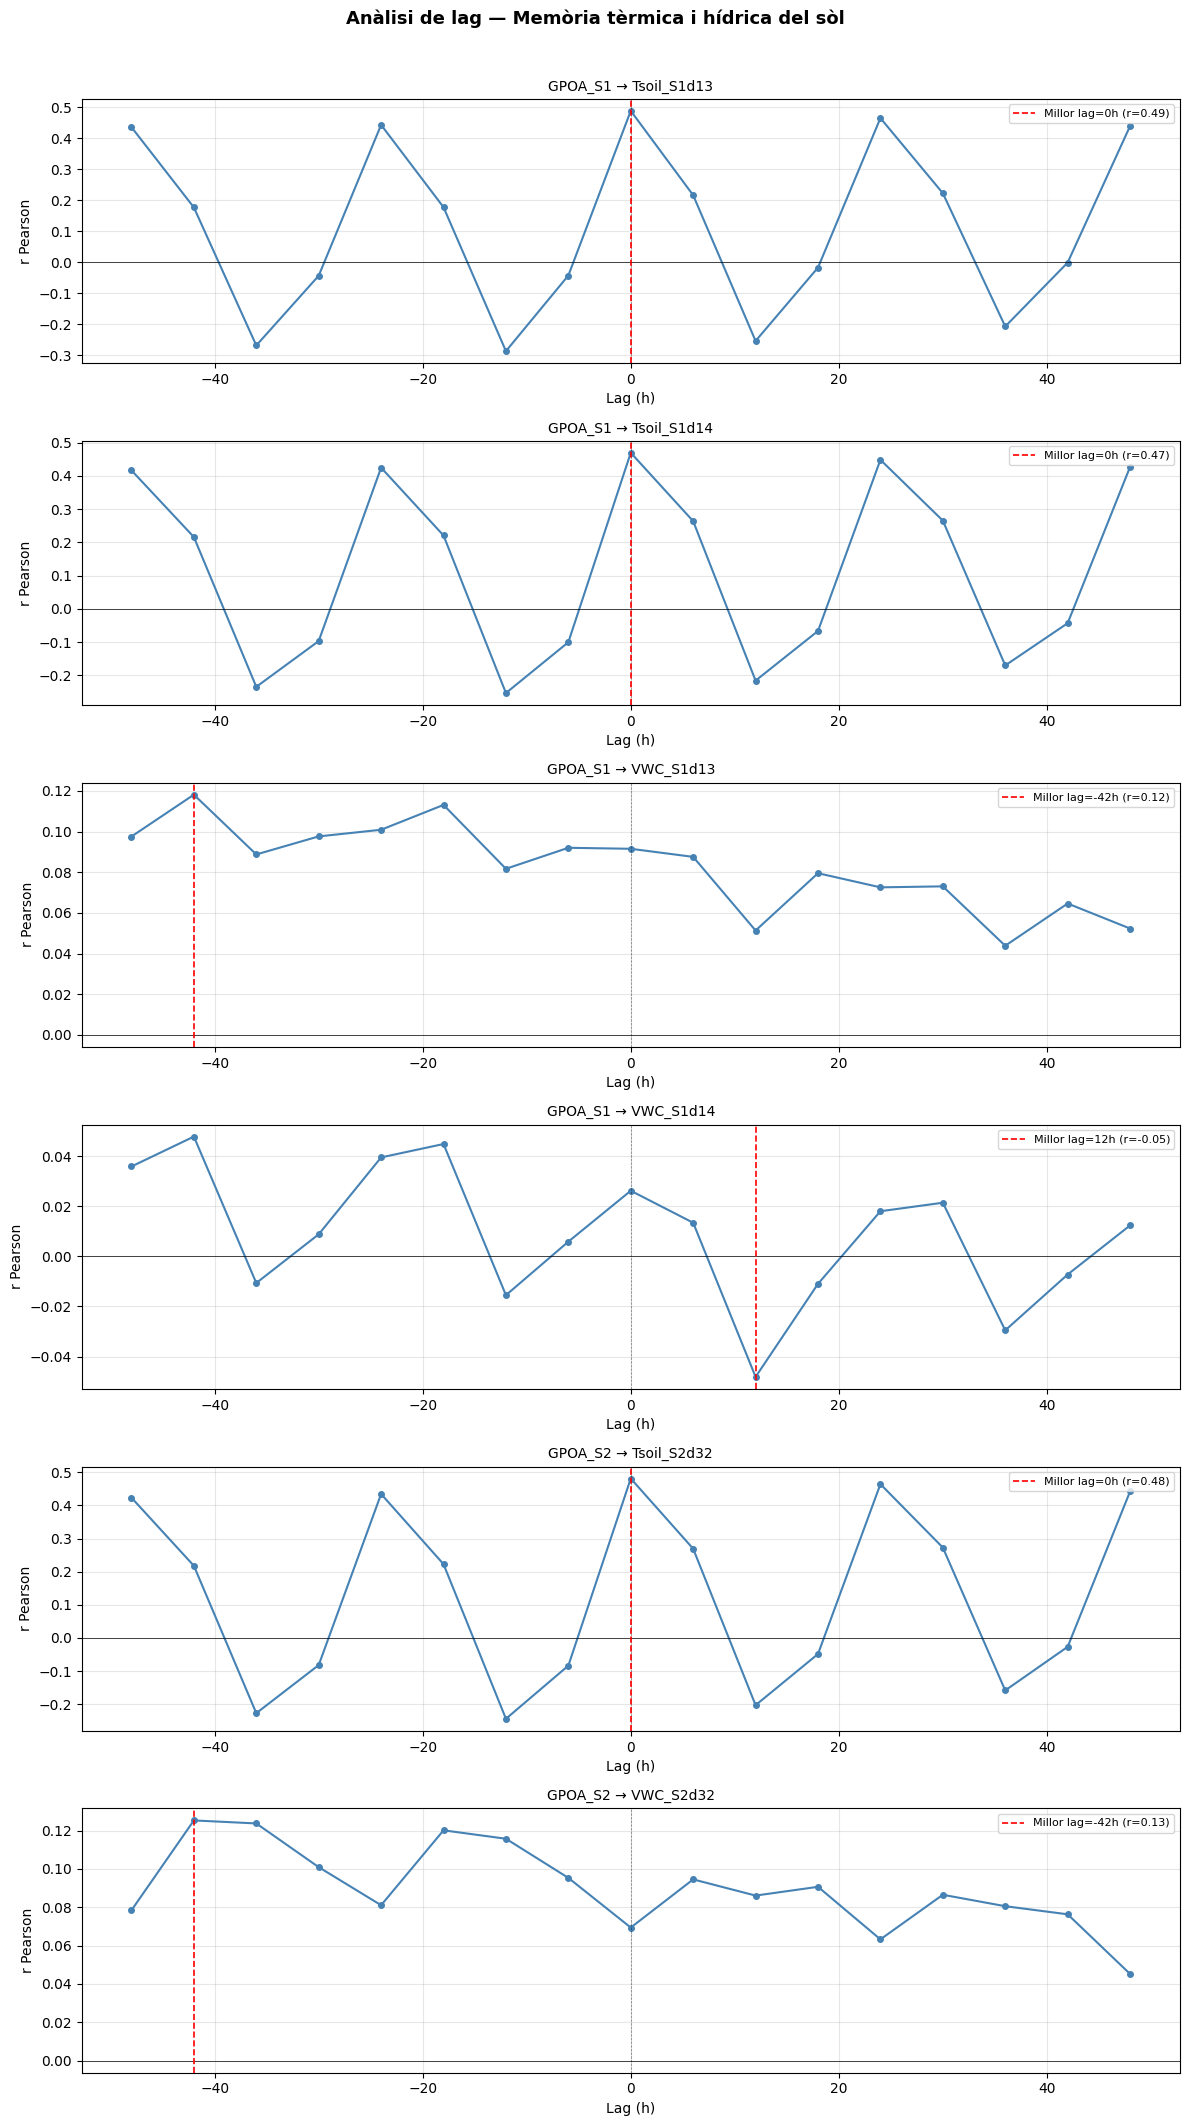

,X (causa),Y (efecte),Millor lag (h),Millor lag (passos 6h),r en millor lag
2,GPOA_S1,VWC_S1d13,-42,-7,0.118
5,GPOA_S2,VWC_S2d32,-42,-7,0.125
1,GPOA_S1,Tsoil_S1d14,0,0,0.470
0,GPOA_S1,Tsoil_S1d13,0,0,0.489
4,GPOA_S2,Tsoil_S2d32,0,0,0.481
3,GPOA_S1,VWC_S1d14,12,2,-0.048


=> Guardat en outputs/lag_analysis.csv


In [82]:
# ── 3. Anàlisi de lag: GPOA → T sòl i VWC ──────────────────────────────────
lag_targets = {
    'GPOA_S1': ['Tsoil_S1d13', 'Tsoil_S1d14', 'VWC_S1d13', 'VWC_S1d14'],
    'GPOA_S2': ['Tsoil_S2d32', 'VWC_S2d32'],
}

LAGS = range(-8, 9)   # ±8 passos de 6h = ±48h

lag_results = []
fig_rows = sum(len(v) for v in lag_targets.values())
fig, axes = plt.subplots(fig_rows, 1, figsize=(12, 3.5 * fig_rows))
axes = np.array(axes).flatten()
ax_idx = 0

for x_col, y_cols in lag_targets.items():
    if x_col not in df.columns:
        continue
    for y_col in y_cols:
        if y_col not in df.columns:
            continue
        joint = df[[x_col, y_col]].dropna()
        if len(joint) < 20:
            continue

        corrs     = [joint[x_col].corr(joint[y_col].shift(-lag)) for lag in LAGS]
        lag_hours = [l * 6 for l in LAGS]
        best_idx  = int(np.argmax(np.abs(corrs)))
        best_lag  = list(LAGS)[best_idx]
        best_r    = corrs[best_idx]

        lag_results.append({
            'X (causa)':        x_col,
            'Y (efecte)':       y_col,
            'Millor lag (h)':   best_lag * 6,
            'Millor lag (passos 6h)': best_lag,
            'r en millor lag':  round(best_r, 3),
        })

        ax = axes[ax_idx]
        ax.plot(lag_hours, corrs, marker='o', markersize=4, color='steelblue')
        ax.axhline(0,  color='black', linewidth=0.5)
        ax.axvline(0,  color='black', linewidth=0.5, linestyle='--', alpha=0.5)
        ax.axvline(best_lag * 6, color='red', linewidth=1.2, linestyle='--',
                   label=f'Millor lag={best_lag*6}h (r={best_r:.2f})')
        ax.set_title(f'{x_col} → {y_col}', fontsize=10)
        ax.set_xlabel('Lag (h)')
        ax.set_ylabel('r Pearson')
        ax.legend(fontsize=8)
        ax_idx += 1

# Amagar eixos sobrants
for ax in axes[ax_idx:]:
    ax.set_visible(False)

plt.suptitle('Anàlisi de lag — Memòria tèrmica i hídrica del sòl',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'lag_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

lag_df = pd.DataFrame(lag_results)
display(lag_df.sort_values('Millor lag (h)'))
lag_df.to_csv(OUT_DIR / 'lag_analysis.csv', index=False)
print('=> Guardat en outputs/lag_analysis.csv')

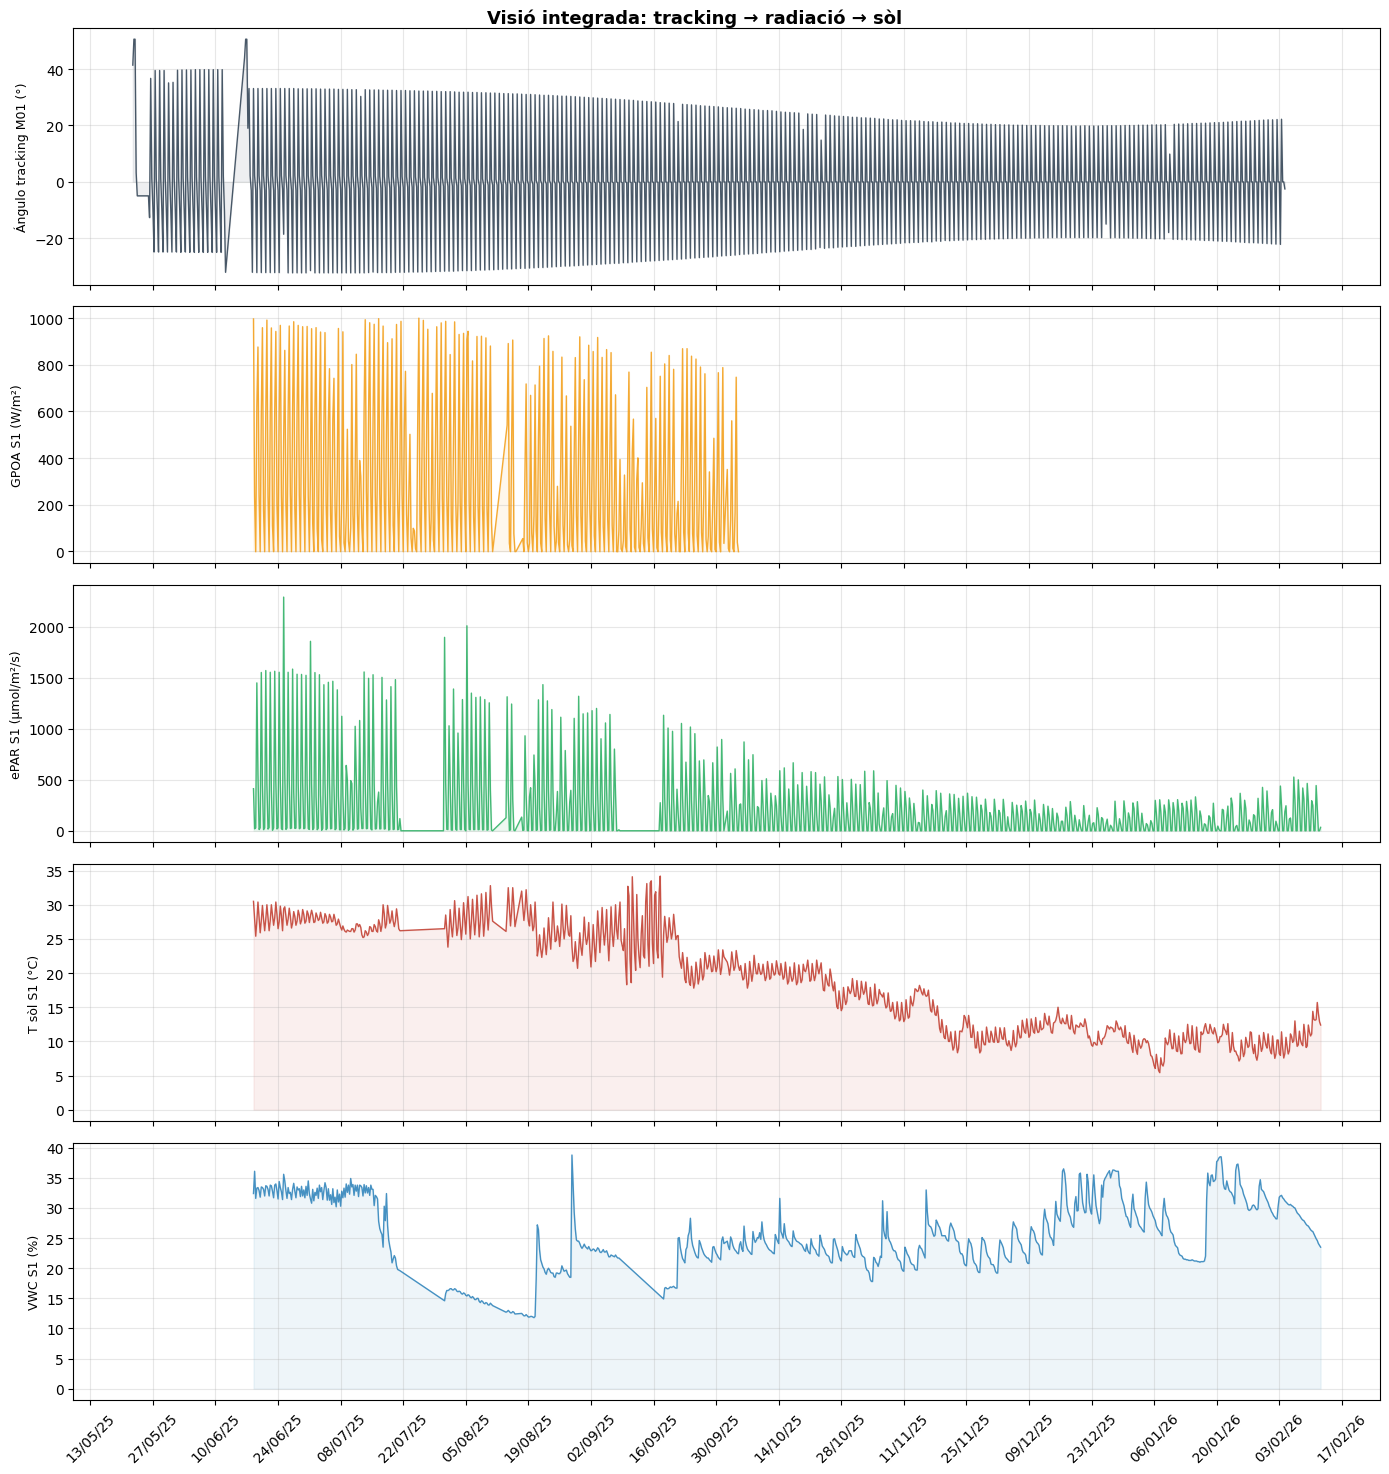

=> Guardat en outputs/integrated_view.png


In [83]:
# ── 4. Evolució temporal conjunta: tracking + ePAR + T sòl + VWC ────────────
plot_vars = [
    ('track_M01', 'Ángulo tracking M01 (°)', '#2c3e50'),
    ('GPOA_S1',   'GPOA S1 (W/m²)',          '#f39c12'),
    ('ePAR_S1d19','ePAR S1 (µmol/m²/s)',      '#27ae60'),
    ('Tsoil_S1d13','T sòl S1 (°C)',           '#c0392b'),
    ('VWC_S1d13', 'VWC S1 (%)',               '#2980b9'),
]
valid_pv = [(col, lbl, c) for col, lbl, c in plot_vars if col in df.columns]

if valid_pv:
    fig, axes = plt.subplots(len(valid_pv), 1,
                             figsize=(14, 3 * len(valid_pv)), sharex=True)
    if len(valid_pv) == 1:
        axes = [axes]
    fig.suptitle('Visió integrada: tracking → radiació → sòl',
                 fontweight='bold', fontsize=13)

    for ax, (col, lbl, color) in zip(axes, valid_pv):
        s = df[col].dropna()
        ax.plot(s.index, s.values, color=color, linewidth=1, alpha=0.85)
        ax.fill_between(s.index, s.values, alpha=0.08, color=color)
        ax.set_ylabel(lbl, fontsize=9)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
    axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'integrated_view.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('=> Guardat en outputs/integrated_view.png')